# 03 — Transfer learning per HistoBreastNet

## 1. Obiettivo e collocazione nel progetto

Questo notebook risponde principalmente alla domanda di ricerca **D1**:

> **Il transfer learning migliora il trade-off tra efficacia predittiva ed efficienza computazionale rispetto a una CNN addestrata da zero?**

Il confronto riguarda la CNN baseline e due backbone pre-addestrati su ImageNet, **MobileNetV2** ed **EfficientNetB0**, valutati sia in modalità **frozen** (backbone congelato) sia in modalità **fine-tuned** (sblocco parziale degli ultimi layer). Il trade-off richiesto da D1 comprende:

- **efficacia predittiva**: accuracy, F1, AUROC e recall della classe positiva `malignant`;
- **efficienza computazionale**: tempo di training, latenza di inferenza, numero di parametri e dimensione del modello.

Il notebook legge i file già preparati in `data/processed/diversity_1p5GB/`: **non crea né modifica subset, split o fold**. Il protocollo principale è la **k-fold patient-wise**, nella quale i pazienti di train, validation e test sono disgiunti; gli esperimenti image-wise e patient-wise a split singolo restano confronti complementari. Il target è binario (`0 = benigno`, `1 = maligno`), mentre sottotipo e magnification sono conservati nelle predizioni per le analisi successive.

Gli output aggregati finali vengono salvati in `results/03_transfer_learning/`; gli artefatti delle singole esecuzioni restano in `experiments/`. Nel protocollo finale il risultato transfer di riferimento è **EfficientNetB0 fine-tuned originale**.

## 2. Setup ambiente, Google Drive e path

In **Google Colab** la cella seguente monta Google Drive e imposta `PROJECT_ROOT` sulla cartella condivisa del progetto. Se la cartella si trova in una posizione diversa, va modificato **solo** il valore assegnato a `PROJECT_ROOT` nel ramo `IN_COLAB`, per esempio `/content/drive/MyDrive/DeepLearning/HistoBreastNet`.

In **locale**, `PROJECT_ROOT` deve indicare la cartella del progetto sul computer. Tutti i path successivi sono relativi a questa root, quindi la stessa pipeline resta utilizzabile nei due ambienti.

I risultati aggregati vengono scritti dentro `results/`, mentre log, predizioni, figure e modelli delle singole run vengono conservati dentro `experiments/`. Se il progetto è su Drive, entrambe le directory sono persistenti e non dipendono dallo spazio temporaneo della sessione Colab. Se il progetto si trova in una sottocartella di Drive, si modifica soltanto il valore di `PROJECT_ROOT` nel ramo Colab.

In [1]:
from pathlib import Path
import os
import sys

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# In Colab si monta Drive; se necessario, modificare soltanto il valore di PROJECT_ROOT.
if IN_COLAB:
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/HistoBreastNet")
else:
    # In locale questo path deve coincidere con la root del progetto.
    PROJECT_ROOT = Path("/Users/bertu/Projects/HistoBreastNet")

# Tutti i path di risultati ed esperimenti saranno derivati da questa root persistente.
os.chdir(PROJECT_ROOT)

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

sys.modules.pop("transfer_learning_utils", None)

from transfer_learning_utils import (
    assert_patient_disjoint,
    concat_and_deduplicate,
    find_baseline_table,
    print_split_statistics,
    resolve_image_path,
    run_protocol,
    safe_read_csv,
    validate_common,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Current working directory:", os.getcwd())
print("Running in Colab:", IN_COLAB)

PROJECT_ROOT: /Users/bertu/Projects/HistoBreastNet
Current working directory: /Users/bertu/Projects/HistoBreastNet
Running in Colab: False


## 3. Configurazione esperimento

`DATASET_CONFIG = "diversity_1p5GB"` identifica il subset a livello di paziente preparato nelle fasi precedenti del progetto. Con `USE_PROCESSED_IMAGE_FOLDER=True`, le immagini vengono lette dalla copia fisica in `data/processed/diversity_1p5GB/images/` quando disponibile; altrimenti viene usata la root originale con un avviso. In entrambi i casi `relative_path` resta invariato.

I flag `RUN_IMAGE_WISE`, `RUN_PATIENT_WISE` e `RUN_KFOLD` selezionano i protocolli da eseguire. Il protocollo finale principale per D1 è la **k-fold patient-wise**. `FAST_DEV_RUN=True` limita i campioni per un controllo tecnico della pipeline e non deve essere usato per produrre risultati finali; `SKIP_EXISTING_RUNS` evita di ripetere combinazioni già complete; `SAVE_MODELS=True` salva i modelli `.keras` nelle cartelle delle singole run.

`BACKBONES_TO_RUN` comprende MobileNetV2 ed EfficientNetB0. Per ciascun backbone, `FROZEN_EPOCHS` definisce la prima fase con backbone congelato e `FINETUNE_EPOCHS` la seconda fase di fine-tuning, inizializzata dai pesi ottenuti nella fase frozen. `UNFREEZE_LAST_N` indica quanti layer finali vengono sbloccati; i layer `BatchNormalization` restano congelati perché, su dataset piccoli, mantenere le statistiche pre-addestrate è generalmente più stabile.

I valori sottostanti appartengono al protocollo sperimentale e non vengono modificati in questa revisione.

In [3]:
import json, random, warnings
import numpy as np
import pandas as pd
import tensorflow as tf

# Subset patient-level preparato nelle fasi precedenti del progetto.
DATASET_CONFIG = 'diversity_1p5GB'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed' / DATASET_CONFIG
ORIGINAL_DATASET_ROOT = PROJECT_ROOT / 'data' / 'original' / 'BreaKHis_v1'
PROCESSED_IMAGES_ROOT = PROCESSED_DIR / 'images'
# True usa la copia fisica delle immagini sotto data/processed/.../images.
USE_PROCESSED_IMAGE_FOLDER = True

# relative_path parte da histology_slides/... ed è sempre risolto rispetto a DATASET_ROOT.
if USE_PROCESSED_IMAGE_FOLDER and PROCESSED_IMAGES_ROOT.exists():
    DATASET_ROOT = PROCESSED_IMAGES_ROOT
    print('Uso copia fisica del subset:', DATASET_ROOT)
else:
    if USE_PROCESSED_IMAGE_FOLDER:
        warnings.warn(
            'Attenzione: copia fisica del subset non trovata. '
            'Uso data/original/BreaKHis_v1.'
        )
    DATASET_ROOT = ORIGINAL_DATASET_ROOT
    print('Uso dataset originale:', DATASET_ROOT)

print('DATASET_ROOT:', DATASET_ROOT)
print('DATASET_ROOT esiste:', DATASET_ROOT.exists())
print('Sorgente immagini:',
      'processed/images' if DATASET_ROOT == PROCESSED_IMAGES_ROOT else 'data/original')
RESULTS_ROOT = PROJECT_ROOT / 'results'
TASK_RESULTS_DIR = RESULTS_ROOT / '03_transfer_learning'
TABLES_DIR = TASK_RESULTS_DIR / 'tables'
FIGURES_DIR = TASK_RESULTS_DIR / 'figures'
PREDICTIONS_DIR = TASK_RESULTS_DIR / 'predictions'
EXPERIMENTS_DIR = PROJECT_ROOT / 'experiments'
MODELS_DIR = PROJECT_ROOT / 'models'

# Se True, esegue lo split image-wise; è un confronto potenzialmente ottimistico,
# perché immagini dello stesso paziente possono trovarsi in partizioni diverse.
# Se False, il relativo blocco viene saltato senza errore.
RUN_IMAGE_WISE = False
# Se True, esegue un singolo split patient-wise con pazienti disgiunti tra train/val/test.
# Se False, il relativo blocco non viene eseguito.
RUN_PATIENT_WISE = False
# Se True, esegue la k-fold patient-wise, protocollo principale del notebook.
# Se False, l'intera sezione k-fold viene saltata.
RUN_KFOLD = True
# Numero massimo di fold da considerare quando FOLDS_TO_RUN è None.
MAX_FOLDS = 5
# None usa tutte le fold disponibili fino a MAX_FOLDS; una lista, es. [0, 1],
# limita l'esecuzione alle sole fold indicate.
FOLDS_TO_RUN = None  # es. [2, 3, 4]; None usa tutte le fold fino a MAX_FOLDS
# Se True, evita di ripetere run già complete; se False, le combinazioni vengono rieseguite.
SKIP_EXISTING_RUNS = False
# Elenco dei backbone pre-addestrati eseguiti in ogni protocollo attivo.
BACKBONES_TO_RUN = ['mobilenetv2', 'efficientnetb0']
# Se True, usa pochi campioni esclusivamente per debug tecnico: non produce risultati finali.
FAST_DEV_RUN = False
CHECK_ALL_IMAGE_PATHS = False  # il controllo completo su Drive può essere lento
# Prima prova consigliata:
# FAST_DEV_RUN = True; RUN_IMAGE_WISE = False; RUN_PATIENT_WISE = True; RUN_KFOLD = False

IMAGE_SIZE = (224, 224)
# Numero di immagini elaborate per aggiornamento; influenza memoria e velocità,
# ma non cambia la composizione degli split.
BATCH_SIZE = 16  # Può essere abbassato a 8 in caso di problemi di memoria
# Epoche massime della prima fase con backbone interamente congelato.
FROZEN_EPOCHS = 15
# Epoche massime della seconda fase, inizializzata dai pesi ottenuti nello stage frozen.
FINETUNE_EPOCHS = 15
# Learning rate della testa quando il backbone è frozen e quindi non viene aggiornato.
FROZEN_LR = 1e-3
# Learning rate più basso per modificare con cautela i pesi pre-addestrati sbloccati.
FINETUNE_LR = 1e-5
# Frazione di attivazioni azzerate nella testa durante il training per limitare overfitting.
DROPOUT_RATE = 0.30
# Numero di layer finali del backbone candidati allo sblocco durante il fine-tuning;
# i layer BatchNormalization restano comunque congelati per maggiore stabilità.
UNFREEZE_LAST_N = 30
# Numero di epoche senza miglioramento tollerate dall'arresto anticipato.
PATIENCE = 4
SEED = 42
# Se True, salva i modelli .keras, necessari anche per il notebook 05.
SAVE_MODELS = True
FAST_SAMPLES_PER_SPLIT = 64
MODEL_ONLY_TIMING_MAX_BATCHES = 5  # caricati una volta in RAM, fuori dal timing
MODEL_ONLY_TIMING_REPEATS = 3

SUPPORTED_BACKBONES = {'mobilenetv2', 'efficientnetb0'}
unsupported_backbones = set(BACKBONES_TO_RUN) - SUPPORTED_BACKBONES
if unsupported_backbones:
    raise ValueError(f'Backbone non supportati: {sorted(unsupported_backbones)}')

TL_CONFIG = {
    'DATASET_CONFIG': DATASET_CONFIG,
    'MAX_FOLDS': MAX_FOLDS,
    'FOLDS_TO_RUN': FOLDS_TO_RUN,
    'IMAGE_SIZE': IMAGE_SIZE,
    'BATCH_SIZE': BATCH_SIZE,
    'FROZEN_EPOCHS': FROZEN_EPOCHS,
    'FINETUNE_EPOCHS': FINETUNE_EPOCHS,
    'FROZEN_LR': FROZEN_LR,
    'FINETUNE_LR': FINETUNE_LR,
    'DROPOUT_RATE': DROPOUT_RATE,
    'UNFREEZE_LAST_N': UNFREEZE_LAST_N,
    'PATIENCE': PATIENCE,
    'SEED': SEED,
    'SAVE_MODELS': SAVE_MODELS,
    'FAST_DEV_RUN': FAST_DEV_RUN,
    'FAST_SAMPLES_PER_SPLIT': FAST_SAMPLES_PER_SPLIT,
    'MODEL_ONLY_TIMING_MAX_BATCHES': MODEL_ONLY_TIMING_MAX_BATCHES,
    'MODEL_ONLY_TIMING_REPEATS': MODEL_ONLY_TIMING_REPEATS,
    'SKIP_EXISTING_RUNS': SKIP_EXISTING_RUNS,
    'EXPERIMENTS_DIR': EXPERIMENTS_DIR,
    'FIGURES_DIR': FIGURES_DIR,
    'PREDICTIONS_DIR': PREDICTIONS_DIR,
}

for directory in [EXPERIMENTS_DIR, MODELS_DIR, TABLES_DIR, FIGURES_DIR, PREDICTIONS_DIR,
                  FIGURES_DIR / 'confusion_matrices',
                  FIGURES_DIR / 'training_curves',
                  FIGURES_DIR / 'roc_curves']:
    directory.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
print('TensorFlow:', tf.__version__, '| GPU:', tf.config.list_physical_devices('GPU'))

Uso copia fisica del subset: /Users/bertu/Projects/HistoBreastNet/data/processed/diversity_1p5GB/images
DATASET_ROOT: /Users/bertu/Projects/HistoBreastNet/data/processed/diversity_1p5GB/images
DATASET_ROOT esiste: True
Sorgente immagini: processed/images
TensorFlow: 2.16.2 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. Caricamento dei CSV prodotti nelle fasi precedenti

Questa sezione **legge senza rigenerare** i file prodotti nelle fasi precedenti del progetto:

- `metadata_subset.csv`: elenco delle immagini e relativi metadati nel subset;
- `image_wise_split.csv`: split non patient-wise, mantenuto soltanto come confronto;
- `patient_wise_split.csv`: split train/validation/test con pazienti disgiunti;
- `patient_wise_folds.csv`: assegnazioni patient-wise usate dalla valutazione k-fold finale;
- `config.json`: configurazione con cui il subset e le partizioni sono stati preparati.

Questi file definiscono il subset, gli split e le fold condivisi dai notebook successivi. Leggerli senza modificarli mantiene coerente il confronto con la CNN baseline: tutti i modelli vengono valutati sugli stessi esempi e sulle stesse partizioni.

In [4]:
# File preparati nelle fasi precedenti: vengono soltanto letti, mai rigenerati.
# Definiscono subset, split e fold condivisi, necessari per un confronto coerente con la baseline.
metadata_subset_path = PROCESSED_DIR / 'metadata_subset.csv'
image_wise_split_path = PROCESSED_DIR / 'image_wise_split.csv'
patient_wise_split_path = PROCESSED_DIR / 'patient_wise_split.csv'
patient_wise_folds_path = PROCESSED_DIR / 'patient_wise_folds.csv'
config_path = PROCESSED_DIR / 'config.json'

INPUT_FILES = {
    'metadata': metadata_subset_path,
    'image_wise': image_wise_split_path,
    'patient_wise': patient_wise_split_path,
    'kfold': patient_wise_folds_path,
    'config': config_path,
}
missing = [str(path) for path in INPUT_FILES.values() if not path.is_file()]
if missing:
    raise FileNotFoundError('File prodotti nelle fasi precedenti mancanti:\n- ' + '\n- '.join(missing))

# Caricamento delle immagini/metadati e delle tre assegnazioni sperimentali condivise.
metadata_df = pd.read_csv(INPUT_FILES['metadata'])
image_wise_df = pd.read_csv(INPUT_FILES['image_wise'])
patient_wise_df = pd.read_csv(INPUT_FILES['patient_wise'])
folds_df = pd.read_csv(INPUT_FILES['kfold'])
with config_path.open(encoding='utf-8') as handle:
    processed_config = json.load(handle)
print({name: len(df) for name, df in {
    'metadata': metadata_df, 'image_wise': image_wise_df,
    'patient_wise': patient_wise_df, 'kfold': folds_df}.items()})

{'metadata': 2838, 'image_wise': 2838, 'patient_wise': 2838, 'kfold': 14190}


## 5. Validazione input, path e split/fold

Prima di costruire i dataset TensorFlow si verificano schema, colonne obbligatorie, label, configurazione e path delle immagini. Questi controlli impediscono che file incompleti o path risolti rispetto a una root errata producano esperimenti non confrontabili.

Per lo split patient-wise e per ogni fold si controlla che train, validation e test contengano pazienti disgiunti. Se immagini dello stesso paziente comparissero in partizioni diverse, il modello potrebbe riconoscere caratteristiche specifiche del paziente già viste in training: questo sarebbe **data leakage** e renderebbe la stima troppo ottimistica. Il protocollo patient-wise è quindi più rigoroso dell'image-wise, che separa le immagini ma non garantisce la separazione dei pazienti.

Nella k-fold si verifica inoltre che ogni paziente entri nel test una sola volta, condizione necessaria per ottenere predizioni out-of-fold complete e non duplicate. Gli errori sono intenzionalmente bloccanti e indicano il CSV, la colonna o la root da controllare.

In [5]:
# Le colonne obbligatorie garantiscono che training, metriche e analisi successive ricevano lo schema atteso.
# La validazione controlla anche che la label binaria sia interpretabile in formato numerico 0/1.
validate_common(metadata_df, INPUT_FILES['metadata'], DATASET_CONFIG)
validate_common(image_wise_df, INPUT_FILES['image_wise'], DATASET_CONFIG, require_split=True)
validate_common(patient_wise_df, INPUT_FILES['patient_wise'], DATASET_CONFIG, require_split=True)
validate_common(folds_df, INPUT_FILES['kfold'], DATASET_CONFIG,
                require_split=True, require_fold=True)
# Gli identificativi di fold vengono convertiti esplicitamente in interi per confronti non ambigui.
folds_df['fold'] = pd.to_numeric(folds_df['fold'], errors='raise').astype(int)

found_folds = set(folds_df['fold'].unique())
if found_folds != set(range(5)):
    raise ValueError(f'{INPUT_FILES["kfold"]}: fold trovate {sorted(found_folds)}, attese [0,1,2,3,4].')

# Pazienti condivisi tra train/validation/test costituirebbero data leakage:
# il modello vedrebbe durante il training caratteristiche dello stesso paziente valutato nel test.
# Per questo la separazione patient-wise è più rigorosa della sola separazione image-wise.
assert_patient_disjoint(patient_wise_df, str(INPUT_FILES['patient_wise']))
for fold in range(5):
    fold_df = folds_df[folds_df['fold'] == fold]
    if set(fold_df['split'].unique()) != {'train', 'val', 'test'}:
        raise ValueError(f'Fold {fold}: devono essere presenti train, val e test.')
    assert_patient_disjoint(fold_df, f'{INPUT_FILES["kfold"]}, fold {fold}')

# Nell'intera 5-fold ogni paziente deve essere assegnato al test una sola volta.
test_counts = (folds_df[folds_df['split'] == 'test']
               .assign(patient_id=lambda x: x['patient_id'].astype(str))
               .groupby('patient_id')['fold'].nunique())
all_patients = set(folds_df['patient_id'].astype(str).unique())
test_patients = set(test_counts.index.astype(str))
missing_from_test = all_patients - test_patients
repeated_in_test = test_counts[test_counts != 1]
if missing_from_test:
    raise ValueError('Alcuni pazienti non compaiono mai nel test della k-fold: '
                     f'{sorted(missing_from_test)[:10]}')
if not repeated_in_test.empty:
    raise ValueError('Alcuni pazienti compaiono nel test in più o meno di una fold:\n'
                     + repeated_in_test.head(10).to_string())

print('Validazione schema, label, config e separazione patient-wise: OK')
print('Validazione k-fold completata: ogni paziente compare nel test esattamente una volta.')

Validazione schema, label, config e separazione patient-wise: OK
Validazione k-fold completata: ogni paziente compare nel test esattamente una volta.


In [6]:
# La cache associa ogni relative_path al path assoluto una sola volta, evitando lavoro ripetuto
# quando la stessa immagine compare nei metadata, nello split singolo e nelle diverse fold.
_resolved_path_cache = {}

# Risolve i path relativi rispetto alle root configurate, così le immagini sono trovate
# sia in locale sia su Colab senza modificare i CSV condivisi.
for df in [metadata_df, image_wise_df, patient_wise_df, folds_df]:
    df['resolved_path'] = df.apply(
        lambda row: resolve_image_path(
            row, DATASET_ROOT, PROJECT_ROOT, cache=_resolved_path_cache
        ),
        axis=1,
    )

# Controllo rapido esplicito prima della costruzione dei dataset TensorFlow.
for name, df in [('metadata', metadata_df), ('image_wise', image_wise_df),
                 ('patient_wise', patient_wise_df), ('kfold', folds_df)]:
    sample_paths = df['resolved_path'].sample(min(20, len(df)), random_state=SEED)
    missing = [path for path in sample_paths if not Path(path).is_file()]
    if missing:
        raise FileNotFoundError('Alcuni path immagine non esistono. Controlla DATASET_ROOT. '
                                f'Dataframe={name}, esempi mancanti: {missing[:5]}')
print('Path immagini validati su un campione di ogni dataframe.')

if CHECK_ALL_IMAGE_PATHS:
    unique_paths = sorted(set().union(*[set(df['resolved_path']) for df in
                                        [metadata_df, image_wise_df, patient_wise_df, folds_df]]))
    missing = [path for path in unique_paths if not Path(path).is_file()]
    if missing:
        raise FileNotFoundError(f'{len(missing)} immagini mancanti; esempi: {missing[:5]}')
    print(f'Controllo completo superato: {len(unique_paths)} immagini uniche.')

Path immagini validati su un campione di ogni dataframe.


In [7]:
print_split_statistics(image_wise_df, 'Split singolo image-wise')
print_split_statistics(patient_wise_df, 'Split singolo patient-wise')
for fold in range(5):
    print_split_statistics(folds_df[folds_df['fold'] == fold], f'Patient-wise fold {fold}')


===== Split singolo image-wise =====

--- train: 1986 immagini, 33 pazienti ---
Immagini per classe:
 binary_label
0    1001
1     985
Pazienti per classe:
 binary_label
0    15
1    18
Immagini per sottotipo:
 subtype_name
lobular_carcinoma      447
adenosis               327
phyllodes_tumor        313
papillary_carcinoma    203
fibroadenoma           191
mucinous_carcinoma     180
tubular_adenoma        170
ductal_carcinoma       155
Immagini per magnification:
 magnification
100X    485
200X    517
400X    470
40X     514

--- test: 426 immagini, 33 pazienti ---
Immagini per classe:
 binary_label
0    215
1    211
Pazienti per classe:
 binary_label
0    15
1    18
Immagini per sottotipo:
 subtype_name
lobular_carcinoma      93
phyllodes_tumor        73
adenosis               53
fibroadenoma           49
mucinous_carcinoma     46
papillary_carcinoma    41
tubular_adenoma        40
ductal_carcinoma       31
Immagini per magnification:
 magnification
100X    121
200X    115
400X     9

## 6. Utility: pipeline `tf.data`, modelli, training, metriche e salvataggio

Le funzioni tecniche riutilizzabili sono raccolte in `notebooks/transfer_learning_utils.py`, così il notebook può concentrarsi sull'orchestrazione dei protocolli, sulla raccolta delle metriche e sul salvataggio degli artefatti. La pipeline `tf.data` carica e prepara le immagini in batch; MobileNetV2 ed EfficientNetB0 ricevono il preprocessing ImageNet coerente con i rispettivi pesi pre-addestrati.

La testa di classificazione usa `GlobalAveragePooling2D`, `Dropout` e un layer `Dense` con attivazione sigmoid. La sigmoid restituisce la probabilità della classe positiva `malignant`. Nello stage **frozen** il backbone è interamente congelato; nello stage **fine-tuned** il training riparte dai pesi frozen e sblocca parzialmente gli ultimi layer. I layer `BatchNormalization` restano congelati per evitare aggiornamenti instabili delle statistiche su un dataset relativamente piccolo.

L'efficienza di inferenza viene misurata in due modi: **end-to-end**, includendo pipeline `tf.data` e accesso ai file, e **model-only**, usando batch già caricati in RAM, warm-up e tre ripetizioni. Per il model-only si salva la mediana per immagine e la deviazione standard delle ripetizioni.

In [8]:
print('Utility tecniche caricate da:', NOTEBOOKS_DIR / 'transfer_learning_utils.py')

Utility tecniche caricate da: /Users/bertu/Projects/HistoBreastNet/notebooks/transfer_learning_utils.py


In [9]:
# Schema comune delle righe per-run/per-fold: identifica modello e protocollo,
# quindi affianca metriche predittive, complessità del modello e tempi di esecuzione.
METRIC_COLUMNS = ['model', 'training_mode', 'dataset_config', 'split_type', 'fold',
                  'accuracy', 'precision', 'recall', 'f1', 'auroc', 'recall_malignant',
                  'n_params', 'n_trainable_params', 'model_size_mb', 'training_time_sec',
                  'avg_epoch_time_sec', 'inference_time_ms_per_image',
                  'end_to_end_inference_time_ms_per_image',
                  'model_only_inference_time_ms_per_image',
                  'model_only_inference_time_ms_std']

In [10]:
# Raccoglie una riga di metriche per ogni run/fold completata.
all_metrics = []
# Raccoglie le predizioni per immagine, poi aggregate nel CSV out-of-fold.
all_predictions = []
# Tiene traccia delle cartelle delle singole run usate o create.
all_experiment_dirs = []

# Le curve di training sono salvate nelle cartelle esperimento da run_protocol;
# il recupero delle run complete è gestito dalla utility tramite SKIP_EXISTING_RUNS.
RUN_CONTEXT = {
    'config': TL_CONFIG,
    'input_files': INPUT_FILES,
    'metrics_store': all_metrics,
    'predictions_store': all_predictions,
    'experiment_dirs_store': all_experiment_dirs,
}

## 7. Esperimento image-wise

Lo split image-wise separa le immagini, ma non garantisce che immagini dello stesso paziente non compaiano sia nel training sia nel test. Può quindi produrre una stima ottimistica, perché caratteristiche patient-specific possono essere viste durante l'addestramento.

Questo protocollo viene mantenuto soltanto come confronto con eventuali risultati image-wise della baseline; **non è il risultato principale** e non dimostra la generalizzazione a pazienti non visti. Se attivato, esegue entrambi i backbone e salva metriche, predizioni e artefatti nelle rispettive cartelle esperimento.

In [10]:
# Il blocco viene eseguito solo con RUN_IMAGE_WISE=True; con False viene saltato senza errore.
# Per MobileNetV2 ed EfficientNetB0, run_protocol salva separatamente stage frozen e fine-tuned.
if RUN_IMAGE_WISE:
    for backbone_name in BACKBONES_TO_RUN:
        display(run_protocol(image_wise_df, 'image_wise',
                             backbone_name=backbone_name, **RUN_CONTEXT))

## 8. Esperimento patient-wise

In questo split train, validation e test contengono pazienti disgiunti. Le prestazioni misurano quindi la generalizzazione su pazienti non visti, aspetto centrale per D2 e più realistico dell'image-wise.

Nel notebook 03 lo split patient-wise singolo è usato soprattutto per coerenza e confronto con gli altri notebook; per il confronto finale D1 si usa la k-fold patient-wise della sezione successiva.

In [11]:
# Il blocco viene eseguito solo con RUN_PATIENT_WISE=True; con False viene saltato senza errore.
# Ogni backbone produce risultati frozen e fine-tuned sul medesimo split patient-wise.
if RUN_PATIENT_WISE:
    for backbone_name in BACKBONES_TO_RUN:
        display(run_protocol(patient_wise_df, 'patient_wise',
                             backbone_name=backbone_name, **RUN_CONTEXT))

## 9. K-fold patient-wise

La k-fold patient-wise è il **protocollo principale** per il confronto finale D1. Si usano esclusivamente le assegnazioni di `patient_wise_folds.csv`: in ogni fold i pazienti di train, validation e test sono disgiunti e, sull'intero ciclo, ogni immagine appartiene al test out-of-fold una sola volta.

Per ogni fold vengono eseguiti MobileNetV2 ed EfficientNetB0, ciascuno negli stage frozen e fine-tuned. Le metriche per-fold vengono poi riassunte con media e deviazione standard, fornendo una stima più robusta della prestazione e della sua variabilità rispetto a uno split singolo.

`FOLDS_TO_RUN=None` usa le fold disponibili fino a `MAX_FOLDS`; una lista esplicita permette di riprendere un sottoinsieme. Con `SKIP_EXISTING_RUNS=True`, una combinazione fold/backbone viene saltata solo se entrambe le fasi hanno tutti gli artefatti richiesti.

In [12]:
# Protocollo principale: con RUN_KFOLD=False l'intero blocco viene saltato senza errore.
# Con None si usano tutte le fold fino a MAX_FOLDS; altrimenti soltanto quelle elencate.
# Per ogni fold selezionata vengono eseguiti entrambi i backbone e i due stage di training.
# run_protocol salva metriche, predizioni out-of-fold, figure e modelli della singola run;
# se SKIP_EXISTING_RUNS è attivo, la utility recupera le combinazioni già complete.
if RUN_KFOLD:
    available_folds = sorted(folds_df['fold'].unique())
    if FOLDS_TO_RUN is None:
        selected_folds = available_folds[:MAX_FOLDS]
    else:
        selected_folds = sorted(set(int(fold) for fold in FOLDS_TO_RUN))
        invalid_folds = set(selected_folds) - set(available_folds)
        if invalid_folds:
            raise ValueError(f'Fold richieste non disponibili: {sorted(invalid_folds)}')
        if not selected_folds:
            raise ValueError('FOLDS_TO_RUN non può essere una sequenza vuota.')
    for fold in selected_folds:
        print(f'\n========== FOLD {fold} / {selected_folds[-1]} ==========')
        fold_data = folds_df[folds_df['fold'] == fold].copy()
        for backbone_name in BACKBONES_TO_RUN:
            print(f'--- Backbone: {backbone_name} ---')
            display(run_protocol(fold_data, 'kfold_patient_wise', fold=int(fold),
                                 backbone_name=backbone_name, **RUN_CONTEXT))


========== FOLD 0 / 4 ==========
--- Backbone: mobilenetv2 ---


2026-07-05 13:52:03.210938: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-05 13:52:03.210962: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-05 13:52:03.210965: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-05 13:52:03.211259: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-05 13:52:03.211268: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/15


/opt/anaconda3/envs/histobreastnet/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-05 13:52:04.564776: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


120/120 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - accuracy: 0.6301 - auc: 0.6819 - loss: 0.6705 - val_accuracy: 0.5000 - val_auc: 0.5778 - val_loss: 0.8109
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.7445 - auc: 0.8173 - loss: 0.5227 - val_accuracy: 0.4720 - val_auc: 0.6161 - val_loss: 0.8397
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.7717 - auc: 0.8550 - loss: 0.4701 - val_accuracy: 0.4393 - val_auc: 0.6090 - val_loss: 0.9701
Epoch 4/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.7968 - auc: 0.8828 - loss: 0.4283 - val_accuracy: 0.5981 - val_auc: 0.6393 - val_loss: 0.7232
Epoch 5/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.8344 - auc: 0.9072 - loss: 0.3899 - val_accuracy: 0.5561 - val_auc: 0.6561 - val_loss: 0.7733
Epoch 6/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.8386 - auc: 0.9125 - loss: 0.3752 - val_accuracy: 0.5023 - val_auc: 0.6527 - val_loss: 0.9222
Epoch 7/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 5

...

Epoch 1/15


/opt/anaconda3/envs/histobreastnet/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


121/121 ━━━━━━━━━━━━━━━━━━━━ 22s 138ms/step - accuracy: 0.8869 - auc: 0.9525 - loss: 0.2990 - val_accuracy: 0.8720 - val_auc: 0.9205 - val_loss: 0.3696
Epoch 2/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - accuracy: 0.8760 - auc: 0.9501 - loss: 0.2979 - val_accuracy: 0.8872 - val_auc: 0.9245 - val_loss: 0.3560
Epoch 3/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.8963 - auc: 0.9581 - loss: 0.2736 - val_accuracy: 0.8829 - val_auc: 0.9295 - val_loss: 0.3322
Epoch 4/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.9046 - auc: 0.9634 - loss: 0.2561 - val_accuracy: 0.8850 - val_auc: 0.9277 - val_loss: 0.3550
Epoch 5/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.8994 - auc: 0.9619 - loss: 0.2577 - val_accuracy: 0.8829 - val_auc: 0.9238 - val_loss: 0.3449
Epoch 6/15
121/121 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.9144 - auc: 0.9693 - loss: 0.2349 - val_accuracy: 0.8829 - val_auc: 0.9306 - val_loss: 0.3481
Epoch 7/15
121/121 ━━━━━━━━━━━━━━━━━━━

2026-07-05 14:19:37.044801: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-07-05 14:19:43.768738: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,accuracy,precision,recall,f1,auroc,recall_malignant,tn,fp,fn,tp,...,training_time_sec,avg_epoch_time_sec,epochs_run,n_train,n_val,model_size_mb,model_size_is_estimate,experiment_id,frozen_stage_time_sec,finetune_stage_time_sec
0,0.790646,0.692029,0.955,0.802521,0.941365,0.955,164,85,9,191,...,161.280984,10.692998,15,1928,461,16.275396,False,20260705_141718_940674_diversity_1p5GB_kfold_p...,NaN,NaN
1,0.839644,0.760163,0.935,0.838565,0.950763,0.935,190,59,13,187,...,298.049247,11.409762,26,1928,461,27.602158,False,20260705_141946_172767_diversity_1p5GB_kfold_p...,161.280984,136.768263


## 10. Aggregazione risultati e riepilogo k-fold

Le tabelle delle singole run possono contenere righe già presenti da esecuzioni precedenti: la deduplicazione conserva una sola riga per combinazione di modello, modalità di training, dataset, protocollo e fold, evitando di pesare due volte lo stesso esperimento.

`transfer_learning_metrics.csv` contiene le metriche **per-run/per-fold**. `transfer_learning_kfold_summary.csv` aggrega invece le fold per modello e modalità di training, riportando media e deviazione standard campionaria (`ddof=1`): la media sintetizza la prestazione attesa, mentre la deviazione standard rende visibile la sensibilità alla composizione delle fold. Un riepilogo con meno di cinque fold è marcato come parziale e non va presentato come risultato finale.

`transfer_learning_predictions.csv` conserva le predizioni per immagine, inclusi paziente, sottotipo e magnification. Le predizioni out-of-fold consentono di costruire ROC e confusion matrix aggregate e forniscono dati riutilizzabili dai notebook 04 e 05 e dalle analisi successive.

È importante distinguere l'**AUROC media fold-by-fold**, ottenuta mediando le AUROC calcolate separatamente, dall'**AUROC out-of-fold aggregata**, calcolata unendo tutte le predizioni di test. Le due quantità possono non coincidere perfettamente perché la prima pesa le fold e la seconda tutte le singole osservazioni in un'unica curva.

In [14]:
# Legge anche il CSV esistente per poter aggiungere nuove fold senza perdere run precedenti.
# La concatenazione deduplica la chiave logica modello/modalità/dataset/protocollo/fold:
# in questo modo la stessa run non viene contata due volte nelle aggregazioni.
metrics_path = TABLES_DIR / 'transfer_learning_metrics.csv'
current_transfer_metrics = (pd.DataFrame(all_metrics) if all_metrics
                            else pd.DataFrame(columns=METRIC_COLUMNS))
existing_transfer_metrics = safe_read_csv(metrics_path)
transfer_metrics = concat_and_deduplicate(
    existing_transfer_metrics,
    current_transfer_metrics,
    ['model', 'training_mode', 'dataset_config', 'split_type', '_fold_key'],
)
if transfer_metrics.empty:
    warnings.warn('Nessun esperimento disponibile: attivare almeno un flag RUN_*.')
transfer_metrics.to_csv(metrics_path, index=False)

# Le predizioni già salvate vengono unite alle nuove e deduplicate anche per immagine/paziente.
# Il CSV risultante serve per ROC e confusion matrix aggregate e per i notebook 04 e 05.
aggregate_predictions_path = PREDICTIONS_DIR / 'transfer_learning_predictions.csv'
current_predictions = (pd.concat(all_predictions, ignore_index=True)
                       if all_predictions else pd.DataFrame())
existing_predictions = safe_read_csv(aggregate_predictions_path)
aggregate_predictions = concat_and_deduplicate(
    existing_predictions,
    current_predictions,
    ['model', 'training_mode', 'dataset_config', 'split_type', '_fold_key',
     'relative_path', 'filename', 'patient_id'],
)
aggregate_predictions.to_csv(aggregate_predictions_path, index=False)

# transfer_learning_metrics.csv resta granulare per run/fold; questo elenco definisce invece
# le colonne riassunte in transfer_learning_kfold_summary.csv come media ± deviazione standard.
summary_metrics = ['accuracy', 'precision', 'recall', 'f1', 'auroc', 'recall_malignant',
                   'training_time_sec', 'avg_epoch_time_sec', 'inference_time_ms_per_image',
                   'end_to_end_inference_time_ms_per_image',
                   'model_only_inference_time_ms_per_image',
                   'model_only_inference_time_ms_std',
                   'n_params', 'n_trainable_params', 'model_size_mb']
kfold_summary_path = TABLES_DIR / 'transfer_learning_kfold_summary.csv'
current_kfold_rows = current_transfer_metrics[
    current_transfer_metrics['split_type'] == 'kfold_patient_wise'
].copy()
UPDATE_KFOLD_OUTPUTS = not FAST_DEV_RUN and not current_kfold_rows.empty

if UPDATE_KFOLD_OUTPUTS:
    kfold_rows = transfer_metrics[
        transfer_metrics['split_type'] == 'kfold_patient_wise'
    ].copy()
    summary_records = []
    for keys, group in kfold_rows.groupby(
        ['dataset_config', 'model', 'training_mode'], dropna=False
    ):
        record = dict(zip(['dataset_config', 'model', 'training_mode'], keys))
        record.update({
            'split_type': 'kfold_patient_wise',
            'k_completed': group['fold'].nunique(),
            'is_complete_5fold': group['fold'].nunique() == 5,
        })
        for metric in summary_metrics:
            record[f'{metric}_mean'] = group[metric].mean()
            record[f'{metric}_std'] = group[metric].std(ddof=1)
        summary_records.append(record)
    current_kfold_summary = pd.DataFrame(summary_records)
    existing_kfold_summary = safe_read_csv(kfold_summary_path)
    kfold_summary = concat_and_deduplicate(
        existing_kfold_summary,
        current_kfold_summary,
        ['model', 'training_mode', 'dataset_config', 'split_type'],
    )
    kfold_summary.to_csv(kfold_summary_path, index=False)
else:
    kfold_summary = safe_read_csv(kfold_summary_path)
    print('Output k-fold ufficiali non aggiornati: nessuna nuova run k-fold non fast-dev.')
display(transfer_metrics[METRIC_COLUMNS])
display(kfold_summary)

,model,training_mode,dataset_config,split_type,fold,accuracy,precision,recall,f1,auroc,recall_malignant,n_params,n_trainable_params,model_size_mb,training_time_sec,avg_epoch_time_sec,inference_time_ms_per_image,end_to_end_inference_time_ms_per_image,model_only_inference_time_ms_per_image,model_only_inference_time_ms_std
0,mobilenetv2,frozen,diversity_1p5GB,kfold_patient_wise,0,0.620968,0.728000,0.371429,0.491892,0.672022,0.371429,2259265,1281,9.194671,89.856438,6.881372,4.411690,4.411690,2.642665,0.034293
1,mobilenetv2,finetuned,diversity_1p5GB,kfold_patient_wise,0,0.604839,0.671329,0.391837,0.494845,0.659110,0.391837,2259265,1512001,20.727475,130.027679,7.191357,4.773973,4.773973,2.632351,0.015546
2,efficientnetb0,frozen,diversity_1p5GB,kfold_patient_wise,0,0.661290,0.853211,0.379592,0.525424,0.774518,0.379592,4050852,1281,16.275396,91.197972,10.088616,6.277236,6.277236,6.696836,0.121571
3,efficientnetb0,finetuned,diversity_1p5GB,kfold_patient_wise,0,0.675403,0.844262,0.420408,0.561308,0.787755,0.420408,4050852,1484641,27.602158,152.913468,10.877594,6.646597,6.646597,6.744501,0.068147
4,mobilenetv2,frozen,diversity_1p5GB,kfold_patient_wise,1,0.561308,0.520343,0.712610,0.601485,0.635610,0.712610,2259265,1281,9.194818,39.454762,6.532625,5.320414,5.320414,2.704252,0.066649
5,mobilenetv2,finetuned,diversity_1p5GB,kfold_patient_wise,1,0.554496,0.515021,0.703812,0.594796,0.653675,0.703812,2259265,1512001,20.727623,95.983293,7.342698,6.407414,6.407414,2.720083,0.072341
6,efficientnetb0,frozen,diversity_1p5GB,kfold_patient_wise,1,0.651226,0.599532,0.750733,0.666667,0.693970,0.750733,4050852,1281,16.275396,110.330953,9.139010,7.846039,7.846039,6.788654,0.043981
7,efficientnetb0,finetuned,diversity_1p5GB,kfold_patient_wise,1,0.643052,0.589569,0.762463,0.664962,0.693448,0.762463,4050852,1484641,27.602158,180.204041,9.957113,8.628351,8.628351,6.872856,0.142935
8,mobilenetv2,frozen,diversity_1p5GB,kfold_patient_wise,2,0.714286,0.770370,0.658228,0.709898,0.807314,0.658228,2259265,1281,9.194818,68.093175,6.763208,6.251210,6.251210,2.734528,0.016910
9,mobilenetv2,finetuned,diversity_1p5GB,kfold_patient_wise,2,0.699160,0.815668,0.560127,0.664165,0.805215,0.560127,2259265,1512001,20.727623,109.640710,7.266609,7.058751,7.058751,2.868377,0.074403


,dataset_config,model,training_mode,split_type,k_completed,is_complete_5fold,accuracy_mean,accuracy_std,precision_mean,precision_std,...,model_only_inference_time_ms_per_image_mean,model_only_inference_time_ms_per_image_std,model_only_inference_time_ms_std_mean,model_only_inference_time_ms_std_std,n_params_mean,n_params_std,n_trainable_params_mean,n_trainable_params_std,model_size_mb_mean,model_size_mb_std
0,diversity_1p5GB,efficientnetb0,finetuned,kfold_patient_wise,5,True,0.745712,0.093641,0.739825,0.099193,...,6.834279,0.137460,0.120055,0.094855,4050852.0,0.0,1484641.0,0.0,27.602158,0.000000
1,diversity_1p5GB,efficientnetb0,frozen,kfold_patient_wise,5,True,0.729033,0.086672,0.727966,0.101165,...,6.798906,0.069631,0.109038,0.055491,4050852.0,0.0,1281.0,0.0,16.275396,0.000000
2,diversity_1p5GB,mobilenetv2,finetuned,kfold_patient_wise,5,True,0.612382,0.070010,0.624325,0.133621,...,2.738507,0.084944,0.058601,0.025009,2259265.0,0.0,1512001.0,0.0,20.727593,0.000066
3,diversity_1p5GB,mobilenetv2,frozen,kfold_patient_wise,5,True,0.618503,0.066068,0.626490,0.121554,...,2.710467,0.044772,0.092061,0.074978,2259265.0,0.0,1281.0,0.0,9.194789,0.000066


## 11. Confronto con la CNN baseline

La CNN baseline è prodotta nel notebook 02 e viene caricata qui, quando i file sono disponibili, per confrontarla con MobileNetV2 ed EfficientNetB0 sugli stessi protocolli. Questo confronto è il riferimento centrale per rispondere a D1 e affianca metriche predittive (accuracy, F1, AUROC, recall malignant) e misure di efficienza (tempi, parametri e dimensione).

La baseline è addestrata da zero e non possiede modalità frozen e fine-tuned: può entrare nei grafici di confronto generale, ma non nel grafico del guadagno del fine-tuning. Le tabelle baseline vengono cercate nelle directory previste; il codice resta robusto e, se non le trova, continua con i soli modelli transfer. Eventuali campi assenti nei file storici vengono normalizzati senza inventare valori.

La curva ROC baseline può essere aggiunta solo quando è disponibile `cnn_baseline_predictions.csv` con una probabilità per immagine: una AUROC media non contiene informazioni sufficienti per ricostruire la curva e non viene usata a questo scopo. La confusion matrix baseline può invece essere ricostruita dai conteggi `tn`, `fp`, `fn`, `tp`; per l'inference time vengono usate soltanto le colonne effettivamente disponibili.

**Nota metodologica:** il confronto baseline-transfer è parte centrale della D1 e rimane quindi in questo notebook. Questa sezione legge risultati già salvati e non rilancia alcun training.

In [16]:
# Directory compatibili con gli output del notebook 02: si cercano metriche per-run
# e riepilogo k-fold senza assumere che entrambi i file siano sempre presenti.
BASELINE_TABLE_DIR_CANDIDATES = [
    # Posizione standard degli output prodotti dal notebook 02.
    RESULTS_ROOT / '02_baseline_cnn' / 'tables',
    # Posizione compatibile con eventuali output storici del progetto.
    RESULTS_ROOT / 'tables',
]

# find_baseline_table cerca prima l'output standard e poi quello storico compatibile.
# Il dettaglio per run/fold serve al confronto D1 tra efficacia ed efficienza.
baseline_metrics_path = find_baseline_table(
    'cnn_baseline_metrics.csv', BASELINE_TABLE_DIR_CANDIDATES)
# Il riepilogo k-fold baseline contiene medie e deviazioni standard confrontabili
# con transfer_learning_kfold_summary.csv nel report finale.
baseline_summary_path = find_baseline_table(
    'cnn_baseline_kfold_summary.csv', BASELINE_TABLE_DIR_CANDIDATES)

comparison_columns = METRIC_COLUMNS
# Se le metriche baseline esistono, vengono filtrate sullo stesso dataset e normalizzate.
# I campi storici mancanti ricevono NaN: non si inventano misure mai calcolate.
# Se il file non è disponibile, il confronto prosegue con i soli modelli transfer.
if baseline_metrics_path is not None:
    # `baseline` rappresenta la tabella di dettaglio trovata, non un nuovo esperimento.
    baseline = safe_read_csv(baseline_metrics_path)
    if 'dataset_config' in baseline.columns:
        baseline = baseline[baseline['dataset_config'] == DATASET_CONFIG].copy()
    else:
        baseline['dataset_config'] = DATASET_CONFIG
    # La baseline è addestrata da zero: il valore completa lo schema, non crea uno stage transfer.
    if 'training_mode' not in baseline: baseline['training_mode'] = 'from_scratch'
    # Se disponibile, per una CNN from-scratch tutti i parametri coincidono con quelli trainabili;
    # altrimenti resta NaN. Non vengono stimati conteggi assenti.
    if 'n_trainable_params' not in baseline: baseline['n_trainable_params'] = baseline.get('n_params', np.nan)
    # Colonne mancanti, incluse model_size_mb e le misure di inferenza, restano NaN:
    # l'aggiunta serve soltanto ad allineare lo schema tabellare senza inventare valori.
    for column in comparison_columns:
        if column not in baseline: baseline[column] = np.nan
    effectiveness_efficiency_comparison = concat_and_deduplicate(
        baseline[comparison_columns],
        transfer_metrics.reindex(columns=comparison_columns),
        ['model', 'training_mode', 'dataset_config', 'split_type', '_fold_key'],
    )
    display(effectiveness_efficiency_comparison)
else:
    # L'assenza del dettaglio baseline non blocca il notebook: viene mantenuta
    # una tabella coerente contenente soltanto i risultati transfer disponibili.
    searched = [str(path / 'cnn_baseline_metrics.csv') for path in BASELINE_TABLE_DIR_CANDIDATES]
    warnings.warn('Baseline non disponibile. Percorsi controllati: ' + ', '.join(searched))
    effectiveness_efficiency_comparison = concat_and_deduplicate(
        None,
        transfer_metrics.reindex(columns=comparison_columns),
        ['model', 'training_mode', 'dataset_config', 'split_type', '_fold_key'],
    )

# Destinazione del confronto k-fold usato nel report D1.
kfold_comparison_path = TABLES_DIR / 'kfold_summary_comparison.csv'
if UPDATE_KFOLD_OUTPUTS and baseline_summary_path is not None:
    # `baseline_kfold_summary` è il riepilogo aggregato della baseline prodotto nel notebook 02.
    baseline_kfold_summary = safe_read_csv(baseline_summary_path)
    if 'dataset_config' in baseline_kfold_summary.columns:
        baseline_kfold_summary = baseline_kfold_summary[
            baseline_kfold_summary['dataset_config'] == DATASET_CONFIG].copy()
    else:
        baseline_kfold_summary['dataset_config'] = DATASET_CONFIG
    # Il file può contenere altri confronti (es. random forest): qui serve la CNN baseline.
    if 'model' in baseline_kfold_summary.columns:
        baseline_kfold_summary = baseline_kfold_summary[
            baseline_kfold_summary['model'].isin(['baseline_cnn', 'cnn_baseline'])].copy()
    # Etichetta neutra necessaria per confrontare lo schema con frozen/fine-tuned.
    baseline_kfold_summary['training_mode'] = 'from_scratch'
    if 'k_completed' not in baseline_kfold_summary.columns:
        baseline_kfold_summary['k_completed'] = baseline_kfold_summary.get('k', np.nan)
    if 'is_complete_5fold' not in baseline_kfold_summary.columns:
        baseline_kfold_summary['is_complete_5fold'] = baseline_kfold_summary['k_completed'].eq(5)
    kfold_summary_comparison = concat_and_deduplicate(
        baseline_kfold_summary,
        kfold_summary,
        ['model', 'training_mode', 'dataset_config', 'split_type'],
    )
    print('Confronto summary k-fold: CNN baseline vs transfer learning')
    display(kfold_summary_comparison)
elif UPDATE_KFOLD_OUTPUTS:
    # Se manca il riepilogo baseline, il riepilogo transfer viene comunque salvato;
    # nessuna media o deviazione standard baseline viene stimata artificialmente.
    searched = [str(path / 'cnn_baseline_kfold_summary.csv')
                for path in BASELINE_TABLE_DIR_CANDIDATES]
    warnings.warn('Summary k-fold baseline non disponibile. Percorsi controllati: '
                  + ', '.join(searched))
    kfold_summary_comparison = kfold_summary.copy()
else:
    kfold_summary_comparison = safe_read_csv(kfold_comparison_path)
    print('Confronto k-fold non aggiornato in questa esecuzione.')

,model,training_mode,dataset_config,split_type,fold,accuracy,precision,recall,f1,auroc,recall_malignant,n_params,n_trainable_params,model_size_mb,training_time_sec,avg_epoch_time_sec,inference_time_ms_per_image,end_to_end_inference_time_ms_per_image,model_only_inference_time_ms_per_image,model_only_inference_time_ms_std
0,baseline_cnn,from_scratch,diversity_1p5GB,image_wise,NaN,0.875587,0.880531,0.876127,0.875284,0.962592,0.933649,258529,258529,3.190000,199.700000,5.390000,0.489000,NaN,NaN,NaN
1,baseline_cnn,from_scratch,diversity_1p5GB,patient_wise,NaN,0.557878,0.278939,0.500000,0.358101,0.936484,0.000000,258529,258529,3.190000,78.660000,7.860000,0.500000,NaN,NaN,NaN
2,baseline_cnn,from_scratch,diversity_1p5GB,kfold_patient_wise,0.0,0.600806,0.779510,0.595918,0.519530,0.820262,0.191837,258529,258529,3.190000,122.810000,6.460000,0.624000,NaN,NaN,NaN
3,baseline_cnn,from_scratch,diversity_1p5GB,kfold_patient_wise,1.0,0.724796,0.758649,0.736600,0.721144,0.764187,0.903226,258529,258529,3.190000,94.450000,6.290000,0.458000,NaN,NaN,NaN
4,baseline_cnn,from_scratch,diversity_1p5GB,kfold_patient_wise,2.0,0.531092,0.265546,0.500000,0.346872,0.769475,1.000000,258529,258529,3.190000,75.670000,7.560000,0.483000,NaN,NaN,NaN
5,baseline_cnn,from_scratch,diversity_1p5GB,kfold_patient_wise,3.0,0.735816,0.814569,0.755447,0.727063,0.869473,0.514754,258529,258529,3.190000,75.680000,7.560000,0.556000,NaN,NaN,NaN
6,baseline_cnn,from_scratch,diversity_1p5GB,kfold_patient_wise,4.0,0.899777,0.908163,0.909639,0.899769,0.955402,1.000000,258529,258529,3.190000,114.820000,6.040000,0.686000,NaN,NaN,NaN
7,mobilenetv2,frozen,diversity_1p5GB,kfold_patient_wise,0.0,0.620968,0.728000,0.371429,0.491892,0.672022,0.371429,2259265,1281,9.194671,89.856438,6.881372,4.411690,4.411690,2.642665,0.034293
8,mobilenetv2,finetuned,diversity_1p5GB,kfold_patient_wise,0.0,0.604839,0.671329,0.391837,0.494845,0.659110,0.391837,2259265,1512001,20.727475,130.027679,7.191357,4.773973,4.773973,2.632351,0.015546
9,efficientnetb0,frozen,diversity_1p5GB,kfold_patient_wise,0.0,0.661290,0.853211,0.379592,0.525424,0.774518,0.379592,4050852,1281,16.275396,91.197972,10.088616,6.277236,6.277236,6.696836,0.121571


Confronto summary k-fold: CNN baseline vs transfer learning


,dataset_config,model,split_type,k,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,...,model_only_inference_time_ms_per_image_mean,model_only_inference_time_ms_per_image_std,model_only_inference_time_ms_std_mean,model_only_inference_time_ms_std_std,n_params_mean,n_params_std,n_trainable_params_mean,n_trainable_params_std,model_size_mb_mean,model_size_mb_std
0,diversity_1p5GB,baseline_cnn,kfold_patient_wise,5.0,0.698500,0.141600,0.705300,0.252400,0.699500,0.157500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,diversity_1p5GB,efficientnetb0,kfold_patient_wise,NaN,0.745712,0.093641,0.739825,0.099193,0.782018,0.215050,...,6.834279,0.137460,0.120055,0.094855,4050852.0,0.0,1484641.0,0.0,27.602158,0.000000
2,diversity_1p5GB,efficientnetb0,kfold_patient_wise,NaN,0.729033,0.086672,0.727966,0.101165,0.763050,0.232917,...,6.798906,0.069631,0.109038,0.055491,4050852.0,0.0,1281.0,0.0,16.275396,0.000000
3,diversity_1p5GB,mobilenetv2,kfold_patient_wise,NaN,0.612382,0.070010,0.624325,0.133621,0.611204,0.189513,...,2.738507,0.084944,0.058601,0.025009,2259265.0,0.0,1512001.0,0.0,20.727593,0.000066
4,diversity_1p5GB,mobilenetv2,kfold_patient_wise,NaN,0.618503,0.066068,0.626490,0.121554,0.615781,0.215222,...,2.710467,0.044772,0.092061,0.074978,2259265.0,0.0,1281.0,0.0,9.194789,0.000066


In [17]:
# Nessuna pulizia post-hoc: aggregate_predictions è già deduplicato in memoria.

## 12. Salvataggio tabelle finali

Gli output aggregati di questo notebook sono salvati sotto `results/03_transfer_learning/`:

- `transfer_learning_metrics.csv`: metriche delle singole run/fold;
- `transfer_learning_kfold_summary.csv`: media e deviazione standard k-fold;
- `efficiency_comparison.csv`: confronto congiunto tra efficacia ed efficienza;
- `kfold_summary_comparison.csv`: riepilogo finale transfer e, quando disponibile, CNN baseline;
- `transfer_learning_predictions.csv`: predizioni per immagine, comprese quelle out-of-fold;
- figure per report in PNG/PDF: ROC, confusion matrix, bar plot delle metriche e grafici di efficienza.

`results/03_transfer_learning/` contiene quindi gli output aggregati, mentre `experiments/` conserva gli artefatti delle singole run. I modelli `.keras` salvati nelle cartelle esperimento sono utilizzabili anche dal notebook 05.

**Nota operativa:** il salvataggio consolida risultati già presenti e nuove run completate; non modifica gli split e non introduce analisi aggiuntive.

In [18]:
# efficiency_comparison.csv affianca efficacia predittiva e costo computazionale per D1.
# Include dati esistenti e nuove run, deduplicati con la stessa chiave logica per-run/per-fold.
efficiency_path = TABLES_DIR / 'efficiency_comparison.csv'
existing_efficiency = safe_read_csv(efficiency_path)
effectiveness_efficiency_comparison = concat_and_deduplicate(
    existing_efficiency,
    effectiveness_efficiency_comparison,
    ['model', 'training_mode', 'dataset_config', 'split_type', '_fold_key'],
)
effectiveness_efficiency_comparison.to_csv(efficiency_path, index=False)

# metrics_path punta a transfer_learning_metrics.csv: una riga per ogni run/fold.
# aggregate_predictions_path punta alle predizioni per immagine, necessarie per ROC,
# confusion matrix aggregate e riuso nei notebook 04 e 05.
saved_paths = [metrics_path, efficiency_path, aggregate_predictions_path]
# kfold_summary_comparison.csv confronta i riepiloghi transfer con la baseline, se disponibile.
if UPDATE_KFOLD_OUTPUTS:
    existing_kfold_comparison = safe_read_csv(kfold_comparison_path)
    kfold_summary_comparison = concat_and_deduplicate(
        existing_kfold_comparison,
        kfold_summary_comparison,
        ['model', 'training_mode', 'dataset_config', 'split_type'],
    )
    kfold_summary_comparison.to_csv(kfold_comparison_path, index=False)
    # transfer_learning_kfold_summary.csv contiene media/deviazione standard dei transfer;
    # kfold_summary_comparison.csv affianca tale riepilogo alla CNN baseline per il report.
    saved_paths.extend([kfold_summary_path, kfold_comparison_path])

print('File salvati:')
for path in saved_paths:
    print('-', path)
print(f'Cartelle esperimento usate o create: {len(all_experiment_dirs)}')
# Le cartelle elencate contengono anche gli eventuali .keras riutilizzabili dal notebook 05.
for path in all_experiment_dirs: print('-', path)

File salvati:
- /Users/bertu/Projects/HistoBreastNet/results/03_transfer_learning/tables/transfer_learning_metrics.csv
- /Users/bertu/Projects/HistoBreastNet/results/03_transfer_learning/tables/efficiency_comparison.csv
- /Users/bertu/Projects/HistoBreastNet/results/03_transfer_learning/predictions/transfer_learning_predictions.csv
- /Users/bertu/Projects/HistoBreastNet/results/03_transfer_learning/tables/transfer_learning_kfold_summary.csv
- /Users/bertu/Projects/HistoBreastNet/results/03_transfer_learning/tables/kfold_summary_comparison.csv
Cartelle esperimento usate o create: 20
- /Users/bertu/Projects/HistoBreastNet/experiments/20260705_135337_375681_diversity_1p5GB_kfold_patient_wise_mobilenetv2_frozen_fold0
- /Users/bertu/Projects/HistoBreastNet/experiments/20260705_135421_862090_diversity_1p5GB_kfold_patient_wise_mobilenetv2_finetuned_fold0
- /Users/bertu/Projects/HistoBreastNet/experiments/20260705_135600_987792_diversity_1p5GB_kfold_patient_wise_efficientnetb0_frozen_fold0
- /

## 13. Commenti interpretativi preliminari su D1

Questa sezione fornisce una lettura interpretativa dei risultati: non introduce nuove analisi e non sostituisce la lettura congiunta delle tabelle e delle figure. Per rispondere a D1 non basta selezionare il valore massimo di accuracy:

1. confrontare MobileNetV2 frozen e fine-tuned con la CNN baseline su **identici split/fold**;
2. dare priorità a F1, AUROC e recall malignant, riportando anche la matrice di confusione;
3. affiancare parametri, dimensione del modello, tempo di training e latenza per immagine;
4. per la k-fold patient-wise riportare media ± deviazione standard e verificare la stabilità tra fold;
5. distinguere eventuali risultati image-wise migliori dalla più rigorosa generalizzazione su pazienti non visti.

F1 e recall malignant sono particolarmente importanti perché gli errori sulla classe maligna hanno maggiore rilevanza clinica. L'AUROC valuta invece la capacità di ordinare le probabilità tra classi indipendentemente dalla soglia operativa; per questo una AUROC alta accompagnata da recall malignant più bassa deve essere discussa, non considerata automaticamente superiore.

La CNN baseline è il riferimento da battere, non un elemento secondario del confronto. Il fine-tuning è vantaggioso solo se il guadagno predittivo rispetto alla baseline e alla variante frozen giustifica l'aumento dei parametri trainabili, del tempo di training, della latenza o della dimensione del modello. Un modello transfer può migliorare alcune metriche ma richiedere più risorse; viceversa, un modello frozen può essere preferibile quando offre prestazioni simili con costo inferiore. Deviazioni standard elevate tra fold indicano instabilità rispetto ai pazienti di test e richiedono conclusioni caute.

Nel protocollo documentato, **EfficientNetB0 fine-tuned originale rimane il modello transfer finale selezionato**. Una sintesi dei risultati deve basarsi esclusivamente sui valori salvati nelle tabelle e nelle figure generate dal notebook. Le analisi per sottotipo e magnification sono rinviate alle fasi successive; le colonne necessarie sono conservate in ogni `predictions.csv`.

## 14. Figure aggregate per report e presentazione

Questa sezione legge i CSV finali in `results/03_transfer_learning/` e genera figure aggregate senza rilanciare il training né modificare i risultati sperimentali.

- **ROC out-of-fold**: valuta il ranking delle probabilità su tutte le immagini di test; la baseline compare soltanto se esistono predizioni per immagine.
- **Confusion matrix aggregate**: mostra i tipi di errore alla soglia 0.5; per la baseline può essere costruita anche dai conteggi `tn/fp/fn/tp`.
- **Bar plot k-fold**: confronta media e variabilità delle metriche tra modelli.
- **Guadagno del fine-tuning**: misura la differenza tra fine-tuned e frozen per ciascun backbone; la baseline non compare perché non possiede questi due stage.
- **Training time, inference time e model complexity**: quantificano l'efficienza computazionale richiesta da D1.
- **Baseline vs miglior modello transfer**: sintetizza il confronto centrale di D1 quando i dati baseline sono disponibili.

La baseline deve essere inclusa nei grafici D1 quando i dati necessari esistono, ma non può essere ricostruita artificialmente: in particolare, una sola AUROC media non permette di disegnare una ROC.

**Nota operativa:** le figure vengono generate qui perché sintetizzano il confronto finale D1. Le celle leggono i CSV salvati e non rilanciano il training.

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# Tutte le figure vengono salvate sia in PNG ad alta risoluzione sia in PDF.
PRESENTATION_DPI = 300

metrics_path = TABLES_DIR / 'transfer_learning_metrics.csv'
summary_path = TABLES_DIR / 'transfer_learning_kfold_summary.csv'
comparison_path = TABLES_DIR / 'kfold_summary_comparison.csv'
efficiency_path = TABLES_DIR / 'efficiency_comparison.csv'
predictions_path = PREDICTIONS_DIR / 'transfer_learning_predictions.csv'
BASELINE_RESULTS_DIR = PROJECT_ROOT / 'results' / '02_baseline_cnn'
# Le predizioni baseline sono opzionali ma indispensabili per disegnarne la ROC:
# una sola AUROC media non contiene i punti necessari per ricostruire la curva.
baseline_predictions_path = (
    BASELINE_RESULTS_DIR / 'predictions' / 'cnn_baseline_predictions.csv'
)
# Metriche dettagliate baseline: possibile sorgente per conteggi tn/fp/fn/tp e tempi.
baseline_metrics_figure_path = BASELINE_RESULTS_DIR / 'tables' / 'cnn_baseline_metrics.csv'
# Riepilogo baseline: possibile sorgente per media/deviazione standard e inferenza.
baseline_summary_figure_path = (
    BASELINE_RESULTS_DIR / 'tables' / 'cnn_baseline_kfold_summary.csv'
)

REPORT_FIGURES_DIR = FIGURES_DIR / 'report'
ROC_DIR = FIGURES_DIR / 'roc_curves'
CM_DIR = FIGURES_DIR / 'confusion_matrices_aggregate'
for directory in [REPORT_FIGURES_DIR, ROC_DIR, CM_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Lettura centralizzata: un CSV obbligatorio blocca la generazione perché la figura
# sarebbe incompleta; un file baseline opzionale restituisce None e il notebook prosegue.
def read_figure_csv(path, description, required=True):
    if not path.is_file():
        if required:
            raise FileNotFoundError(
                f'CSV necessario per le figure mancante ({description}): {path}'
            )
        return None
    return pd.read_csv(path)

# Seleziona esclusivamente risultati finali comparabili: elimina eventuali run fast-dev,
# protocolli diversi dalla k-fold patient-wise e configurazioni dataset non pertinenti.
def filter_final_rows(df, source_name):
    filtered = df.copy()
    # I run di debug non devono contribuire alle figure o alle conclusioni D1.
    if 'fast_dev_run' in filtered.columns:
        fast_flag = filtered['fast_dev_run']
        if pd.api.types.is_bool_dtype(fast_flag):
            filtered = filtered[fast_flag == False].copy()
        else:
            normalized = fast_flag.astype(str).str.strip().str.lower()
            filtered = filtered[normalized.isin(['false', '0', 'no'])].copy()
    # Le figure finali usano il protocollo principale, non i confronti image-wise/singolo split.
    if 'split_type' in filtered.columns:
        filtered = filtered[filtered['split_type'] == 'kfold_patient_wise'].copy()
    # Evita di combinare risultati ottenuti su subset differenti.
    if 'dataset_config' in filtered.columns:
        filtered = filtered[filtered['dataset_config'] == 'diversity_1p5GB'].copy()
    if filtered.empty:
        raise ValueError(
            f'{source_name}: nessuna riga finale per diversity_1p5GB / kfold_patient_wise.'
        )
    return filtered

# Applica alla baseline gli stessi filtri metodologici, ma accetta None perché i relativi
# file sono opzionali e la mancanza non deve impedire le figure dei modelli transfer.
def filter_optional_baseline_rows(df):
    if df is None:
        return None
    filtered = df.copy()
    if 'fast_dev_run' in filtered.columns:
        fast_flag = filtered['fast_dev_run']
        if pd.api.types.is_bool_dtype(fast_flag):
            filtered = filtered[fast_flag == False].copy()
        else:
            normalized = fast_flag.astype(str).str.strip().str.lower()
            filtered = filtered[normalized.isin(['false', '0', 'no'])].copy()
    if 'split_type' in filtered.columns:
        filtered = filtered[filtered['split_type'] == 'kfold_patient_wise'].copy()
    if 'dataset_config' in filtered.columns:
        filtered = filtered[filtered['dataset_config'] == 'diversity_1p5GB'].copy()
    return filtered

# Alcuni CSV storici usano nomi alternativi: prende la prima colonna compatibile;
# se nessuna esiste, fallisce esplicitamente invece di usare dati sbagliati.
def require_column(df, candidates, source_name, purpose):
    column = next((name for name in candidates if name in df.columns), None)
    if column is None:
        raise ValueError(
            f'{source_name}: colonna per {purpose} mancante. '
            f'Colonne cercate: {candidates}; disponibili: {list(df.columns)}'
        )
    return column

# Uniforma maiuscole, spazi, trattini e underscore: nomi equivalenti come
# "baseline_cnn" e "Baseline CNN" diventano confrontabili senza cambiare i CSV.
def canonical_token(value):
    return ''.join(character for character in str(value).lower() if character.isalnum())

# Etichette leggibili per le figure; le chiavi canoniche restano separate dai nomi visualizzati.
MODEL_LABELS = {
    ('baselinecnn', 'fromscratch'): 'Baseline CNN\nfrom scratch',
    ('mobilenetv2', 'frozen'): 'MobileNetV2\nfrozen',
    ('mobilenetv2', 'finetuned'): 'MobileNetV2\nfine-tuned',
    ('efficientnetb0', 'frozen'): 'EfficientNetB0\nfrozen',
    ('efficientnetb0', 'finetuned'): 'EfficientNetB0\nfine-tuned',
}
TRANSFER_SPECS = [
    ('mobilenetv2', 'frozen'),
    ('mobilenetv2', 'finetuned'),
    ('efficientnetb0', 'frozen'),
    ('efficientnetb0', 'finetuned'),
]
# La baseline entra nei confronti generali, mentre TRANSFER_SPECS resta l'insieme usato
# nei grafici che richiedono esplicitamente gli stage frozen e fine-tuned.
COMPARISON_SPECS = [('baselinecnn', 'fromscratch')] + TRANSFER_SPECS

# Aggiunge chiavi standardizzate per modello e modalità di training; non modifica
# le colonne originali e rende robusto l'incrocio tra file prodotti in momenti diversi.
def add_canonical_config(df, source_name):
    model_column = require_column(df, ['model', 'model_name', 'backbone'], source_name, 'modello')
    mode_column = require_column(
        df, ['training_mode', 'mode', 'phase'], source_name, 'configurazione di training'
    )
    result = df.copy()
    result['_model_key'] = result[model_column].map(canonical_token)
    result['_mode_key'] = result[mode_column].map(canonical_token)
    return result

# Seleziona soltanto le configurazioni previste dalla figura e segnala subito quelle mancanti,
# evitando grafici apparentemente completi costruiti su un sottoinsieme accidentale.
def select_config_rows(df, specs, source_name):
    configured = add_canonical_config(df, source_name)
    rows = []
    for spec in specs:
        matches = configured[
            (configured['_model_key'] == spec[0]) & (configured['_mode_key'] == spec[1])
        ]
        if matches.empty:
            raise ValueError(
                f'{source_name}: configurazione mancante: {MODEL_LABELS.get(spec, spec)}'
            )
        rows.append(matches.iloc[-1])
    return pd.DataFrame(rows).reset_index(drop=True)

# Salva ogni figura in PNG ad alta risoluzione per le presentazioni e in PDF per il report;
# restituisce entrambi i path per costruire l'elenco finale degli artefatti.
def save_png_pdf(fig, base_path):
    png_path = base_path.with_suffix('.png')
    pdf_path = base_path.with_suffix('.pdf')
    fig.savefig(png_path, dpi=PRESENTATION_DPI, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    return [png_path, pdf_path]

metrics_df = filter_final_rows(
    read_figure_csv(metrics_path, 'metriche transfer learning'), metrics_path.name
)
summary_df = filter_final_rows(
    read_figure_csv(summary_path, 'summary k-fold transfer learning'), summary_path.name
)
comparison_raw = read_figure_csv(
    comparison_path, 'confronto k-fold con baseline', required=False
)
# Il confronto generale include la baseline soltanto quando il CSV compatibile è disponibile.
comparison_df = (
    filter_final_rows(comparison_raw, comparison_path.name)
    if comparison_raw is not None else None
)
efficiency_df = filter_final_rows(
    read_figure_csv(efficiency_path, 'confronto di efficienza'), efficiency_path.name
)
predictions_df = filter_final_rows(
    read_figure_csv(predictions_path, 'predizioni out-of-fold'), predictions_path.name
)
# Le due tabelle baseline sono opzionali: vengono usate soltanto se presenti e compatibili.
baseline_metrics_figure_df = filter_optional_baseline_rows(
    read_figure_csv(
        baseline_metrics_figure_path, 'metriche CNN baseline', required=False
    )
)
baseline_summary_figure_df = filter_optional_baseline_rows(
    read_figure_csv(
        baseline_summary_figure_path, 'summary k-fold CNN baseline', required=False
    )
)

print('CSV caricati per le figure aggregate (nessun training eseguito).')

CSV caricati per le figure aggregate (nessun training eseguito).


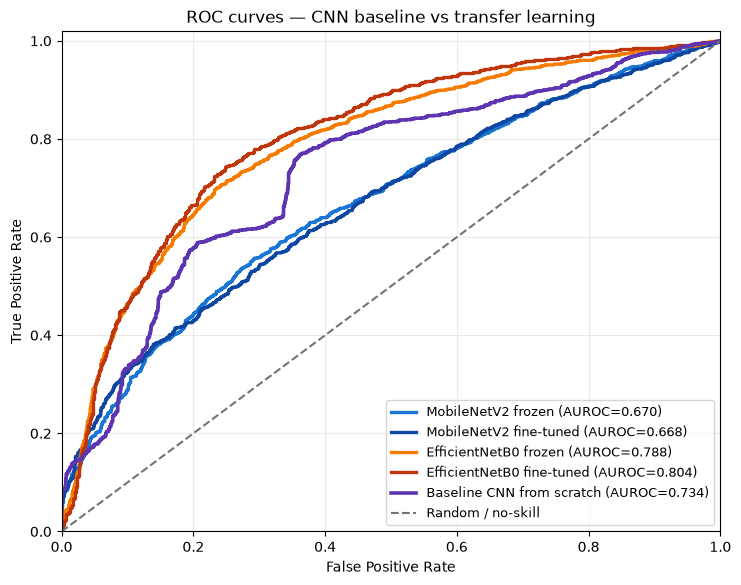

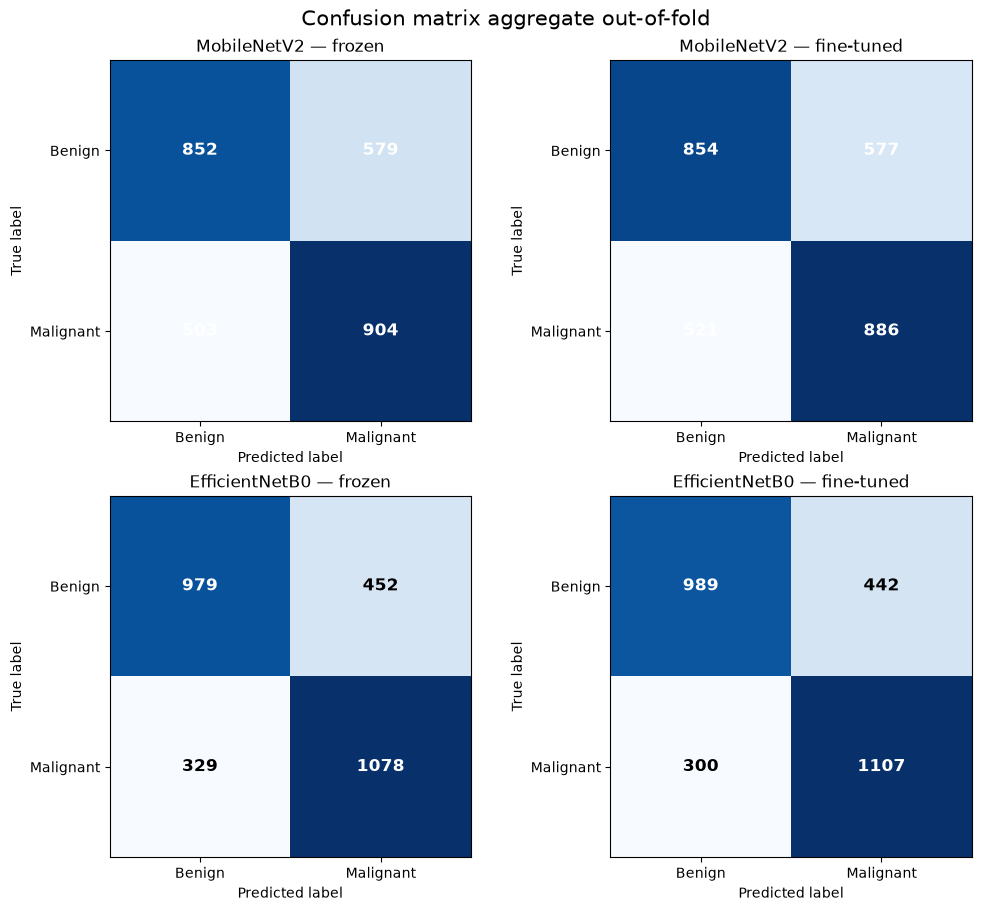

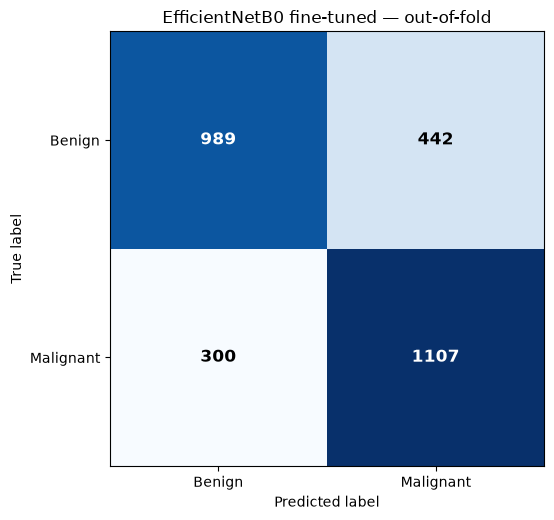

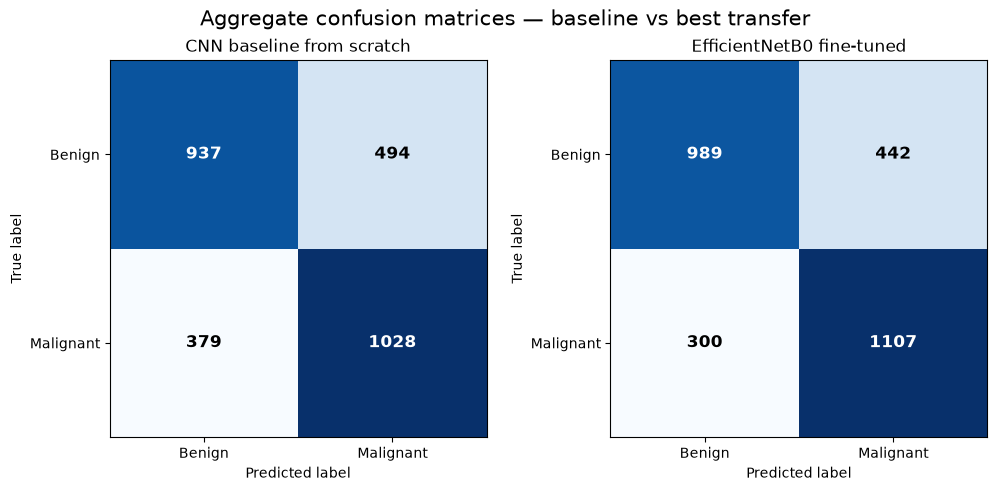

In [12]:
# ROC aggregate e confusion matrix out-of-fold.
prediction_source = predictions_path.name
predictions_plot = add_canonical_config(predictions_df, prediction_source)
target_column = require_column(
    predictions_plot, ['binary_label', 'y_true'], prediction_source, 'target binario'
)
score_column = require_column(
    predictions_plot, ['y_prob', 'y_score', 'probability'], prediction_source, 'probabilità maligna'
)

# Se sono presenti run ripetute, conserva la run più recente per fold e immagine.
# La deduplicazione impedisce che la stessa immagine pesi più volte nella ROC o nella
# confusion matrix: ogni configurazione deve contribuire con una sola previsione out-of-fold.
image_id_column = next(
    (name for name in ['relative_path', 'filename'] if name in predictions_plot.columns), None
)
# Modello, modalità, fold e identificativo immagine definiscono una predizione univoca.
dedup_columns = ['_model_key', '_mode_key']
if 'fold' in predictions_plot.columns:
    dedup_columns.append('fold')
if image_id_column is not None:
    dedup_columns.append(image_id_column)
if image_id_column is not None:
    if 'experiment_id' in predictions_plot.columns:
        predictions_plot = predictions_plot.sort_values('experiment_id')
    predictions_plot = predictions_plot.drop_duplicates(dedup_columns, keep='last')

prediction_groups = {}
for spec in TRANSFER_SPECS:
    group = predictions_plot[
        (predictions_plot['_model_key'] == spec[0])
        & (predictions_plot['_mode_key'] == spec[1])
    ].copy()
    if group.empty:
        raise ValueError(
            f'{prediction_source}: predizioni mancanti per {MODEL_LABELS[spec]}'
        )
    y_true_values = pd.to_numeric(group[target_column], errors='raise').astype(int).to_numpy()
    # La ROC richiede uno score continuo: y_prob permette di valutare tutte le soglie,
    # mentre una sola classe y_pred descriverebbe soltanto un punto operativo.
    y_score_values = pd.to_numeric(group[score_column], errors='raise').to_numpy()
    if set(np.unique(y_true_values)) != {0, 1}:
        raise ValueError(f'{prediction_source}: {MODEL_LABELS[spec]} non contiene entrambe le classi.')
    prediction_groups[spec] = (y_true_values, y_score_values)

# La baseline viene aggiunta solo con dati realmente disponibili: nessuna ROC è inferita dall'AUROC media.
baseline_prediction_group = None
baseline_prediction_cm = None
# Se il file esiste, carica le predizioni baseline prodotte dal notebook 02 e le filtra
# sul protocollo k-fold patient-wise e sulla configurazione from-scratch.
if baseline_predictions_path.exists():
    baseline_predictions = filter_optional_baseline_rows(
        pd.read_csv(baseline_predictions_path)
    )
    if baseline_predictions is not None and not baseline_predictions.empty:
        if 'model' in baseline_predictions.columns:
            baseline_model_key = baseline_predictions['model'].map(canonical_token)
            baseline_predictions = baseline_predictions[
                baseline_model_key.isin(['baselinecnn', 'cnnbaseline'])
            ].copy()
        if 'training_mode' in baseline_predictions.columns:
            baseline_mode_key = baseline_predictions['training_mode'].map(canonical_token)
            baseline_predictions = baseline_predictions[
                baseline_mode_key == 'fromscratch'
            ].copy()
    if baseline_predictions is None or baseline_predictions.empty:
        warnings.warn(
            'cnn_baseline_predictions.csv non contiene predizioni k-fold patient-wise '
            'della CNN baseline: ROC baseline non aggiunta.'
        )
    else:
        baseline_target_column = next(
            (name for name in ['y_true', 'binary_label'] if name in baseline_predictions.columns),
            None,
        )
        if baseline_target_column is None:
            warnings.warn(
                'cnn_baseline_predictions.csv deve contenere y_true o binary_label: '
                'ROC e confusion matrix baseline non aggiunte.'
            )
        else:
            # Anche le predizioni baseline devono essere univoche per fold e immagine,
            # altrimenti avrebbero un peso diverso rispetto ai modelli transfer.
            baseline_dedup_columns = []
            if 'fold' in baseline_predictions.columns:
                baseline_dedup_columns.append('fold')
            baseline_image_column = next(
                (name for name in ['relative_path', 'filename']
                 if name in baseline_predictions.columns),
                None,
            )
            if baseline_image_column is not None:
                baseline_dedup_columns.append(baseline_image_column)
            if baseline_dedup_columns:
                if 'experiment_id' in baseline_predictions.columns:
                    baseline_predictions = baseline_predictions.sort_values('experiment_id')
                baseline_predictions = baseline_predictions.drop_duplicates(
                    baseline_dedup_columns, keep='last'
                )
            baseline_y_true = pd.to_numeric(
                baseline_predictions[baseline_target_column], errors='raise'
            ).astype(int).to_numpy()
            # y_prob consente sia ROC sia confusion matrix alla soglia 0.5.
            if 'y_prob' in baseline_predictions.columns:
                baseline_y_score = pd.to_numeric(
                    baseline_predictions['y_prob'], errors='raise'
                ).to_numpy()
                if set(np.unique(baseline_y_true)) == {0, 1}:
                    baseline_prediction_group = (baseline_y_true, baseline_y_score)
                    baseline_prediction_cm = confusion_matrix(
                        baseline_y_true, (baseline_y_score >= 0.5).astype(int), labels=[0, 1]
                    )
                else:
                    warnings.warn(
                        'Predizioni CNN baseline prive di entrambe le classi: '
                        'ROC baseline non aggiunta.'
                    )
            # Con sole classi predette si può costruire la confusion matrix, non la ROC.
            elif 'y_pred' in baseline_predictions.columns:
                baseline_y_pred = pd.to_numeric(
                    baseline_predictions['y_pred'], errors='raise'
                ).astype(int).to_numpy()
                baseline_prediction_cm = confusion_matrix(
                    baseline_y_true, baseline_y_pred, labels=[0, 1]
                )
                warnings.warn(
                    'cnn_baseline_predictions.csv non contiene y_prob: '
                    'confusion matrix baseline disponibile, ROC baseline non aggiunta.'
                )
            else:
                warnings.warn(
                    'cnn_baseline_predictions.csv non contiene y_prob o y_pred: '
                    'ROC e confusion matrix baseline non aggiunte.'
                )
else:
    print('Predizioni CNN baseline non trovate: ROC baseline non aggiunta.')

# Calcolo delle ROC sulle predizioni out-of-fold aggregate di ciascuna configurazione.
# La baseline viene aggiunta solo se baseline_prediction_group contiene probabilità per immagine.
saved_figure_paths = []
fig, ax = plt.subplots(figsize=(8.5, 6.5))
colors = ['#1976D2', '#0D47A1', '#F57C00', '#BF360C']
for spec, color in zip(TRANSFER_SPECS, colors):
    y_true_values, y_score_values = prediction_groups[spec]
    false_positive_rate, true_positive_rate, _ = roc_curve(y_true_values, y_score_values)
    auc_value = roc_auc_score(y_true_values, y_score_values)
    ax.plot(
        false_positive_rate, true_positive_rate, linewidth=2.4, color=color,
        label=f'{MODEL_LABELS[spec].replace(chr(10), " ")} (AUROC={auc_value:.3f})'
    )
# La curva baseline viene disegnata solo con probabilità per immagine; una AUROC media
# non consente di ricostruire le coppie FPR/TPR alle diverse soglie.
if baseline_prediction_group is not None:
    baseline_y_true, baseline_y_score = baseline_prediction_group
    baseline_fpr, baseline_tpr, _ = roc_curve(baseline_y_true, baseline_y_score)
    baseline_auc = roc_auc_score(baseline_y_true, baseline_y_score)
    ax.plot(
        baseline_fpr, baseline_tpr, linewidth=2.6, color='#5E35B1',
        label=f'Baseline CNN from scratch (AUROC={baseline_auc:.3f})'
    )
ax.plot([0, 1], [0, 1], linestyle='--', color='0.45', linewidth=1.5, label='Random / no-skill')
roc_title = (
    'ROC curves — CNN baseline vs transfer learning'
    if baseline_prediction_group is not None
    else 'Transfer learning ROC curves — out-of-fold'
)
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate', title=roc_title)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend(loc='lower right', fontsize=9)
saved_figure_paths.extend(save_png_pdf(fig, ROC_DIR / 'roc_transfer_models'))
plt.show()
plt.close(fig)

# Helper comune: mantiene identico lo stile delle matrici transfer e baseline.
def draw_confusion_matrix(ax, cm, title):
    image = ax.imshow(cm, cmap='Blues')
    threshold = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            # Testo bianco sulle celle scure e nero sulle celle chiare per mantenere leggibilità.
            color = 'white' if value > threshold else 'black'
            ax.text(
                j, i, str(value), ha='center', va='center', color=color,
                fontsize=12, fontweight='bold'
            )
    ax.set_xticks([0, 1], labels=['Benign', 'Malignant'])
    ax.set_yticks([0, 1], labels=['Benign', 'Malignant'])
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title(title)
    return image

# Le confusion matrix aggregate applicano la soglia 0.5 alle predizioni out-of-fold.
confusion_matrices = {}
fig, axes = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=True)
for ax, spec in zip(axes.flat, TRANSFER_SPECS):
    y_true_values, y_score_values = prediction_groups[spec]
    # La soglia 0.5 trasforma la probabilità maligna nella classe usata dalla matrice.
    y_pred_values = (y_score_values >= 0.5).astype(int)
    matrix = confusion_matrix(y_true_values, y_pred_values, labels=[0, 1])
    confusion_matrices[spec] = matrix
    draw_confusion_matrix(ax, matrix, MODEL_LABELS[spec].replace('\n', ' — '))
fig.suptitle('Confusion matrix aggregate out-of-fold', fontsize=15)
saved_figure_paths.extend(
    save_png_pdf(fig, CM_DIR / 'confusion_matrices_transfer_models')
)
plt.show()
plt.close(fig)

# Matrice aggregata del modello transfer finale: ogni immagine è valutata nella fold
# in cui apparteneva al test set, quindi le predizioni sono realmente out-of-fold.
best_spec = ('efficientnetb0', 'finetuned')
fig, ax = plt.subplots(figsize=(6, 5.3))
draw_confusion_matrix(
    ax, confusion_matrices[best_spec], 'EfficientNetB0 fine-tuned — out-of-fold'
)
fig.tight_layout()
saved_figure_paths.extend(
    save_png_pdf(fig, CM_DIR / 'confusion_matrix_efficientnetb0_finetuned')
)
plt.show()
plt.close(fig)

def baseline_count_rows(df):
    if df is None or df.empty:
        return None
    rows = df.copy()
    if 'model' in rows.columns:
        model_key = rows['model'].map(canonical_token)
        rows = rows[model_key.isin(['baselinecnn', 'cnnbaseline'])].copy()
    if 'training_mode' in rows.columns:
        mode_key = rows['training_mode'].map(canonical_token)
        rows = rows[mode_key == 'fromscratch'].copy()
    return rows

# Se la baseline non ha predizioni per immagine ma conserva tn/fp/fn/tp, la matrice
# può essere ricostruita sommando i conteggi; questo non sarebbe sufficiente per una ROC.
cm_baseline = baseline_prediction_cm
if cm_baseline is not None:
    pass
else:
    baseline_count_sources = [
        (baseline_metrics_figure_df, baseline_metrics_figure_path.name),
        (comparison_df, comparison_path.name),
    ]
    for count_source_df, count_source_name in baseline_count_sources:
        count_rows = baseline_count_rows(count_source_df)
        if count_rows is None or count_rows.empty:
            continue
        if all(column in count_rows.columns for column in ['tn', 'fp', 'fn', 'tp']):
            counts = count_rows[['tn', 'fp', 'fn', 'tp']].apply(
                pd.to_numeric, errors='coerce'
            )
            # Si usano soltanto righe con tutti e quattro i conteggi disponibili:
            # valori incompleti non vengono sostituiti o stimati.
            if counts.notna().all(axis=1).any():
                tn_sum, fp_sum, fn_sum, tp_sum = counts.dropna().sum().astype(int)
                cm_baseline = np.array([[tn_sum, fp_sum], [fn_sum, tp_sum]])
                print(f'Confusion matrix baseline ricostruita da: {count_source_name}')
                break

if cm_baseline is None:
    warnings.warn(
        'Predizioni o conteggi tn/fp/fn/tp della CNN baseline non disponibili: '
        'confusion_matrix_baseline_vs_best_transfer non generata.'
    )
else:
    # Con dati compatibili, affianca baseline e miglior transfer nella figura D1.
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.8), constrained_layout=True)
    draw_confusion_matrix(axes[0], cm_baseline, 'CNN baseline from scratch')
    draw_confusion_matrix(
        axes[1], confusion_matrices[best_spec], 'EfficientNetB0 fine-tuned'
    )
    fig.suptitle('Aggregate confusion matrices — baseline vs best transfer', fontsize=15)
    saved_figure_paths.extend(
        save_png_pdf(fig, CM_DIR / 'confusion_matrix_baseline_vs_best_transfer')
    )
    plt.show()
    plt.close(fig)

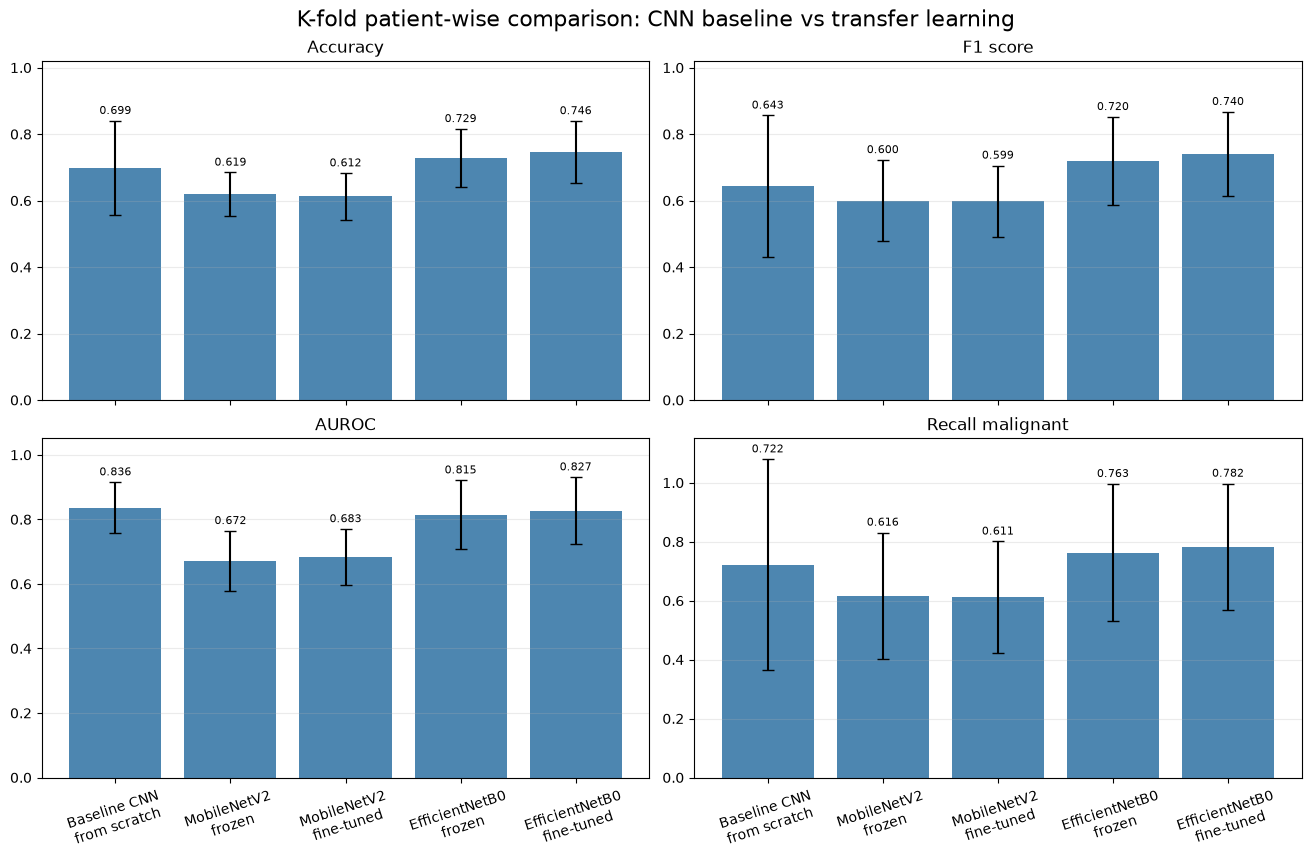

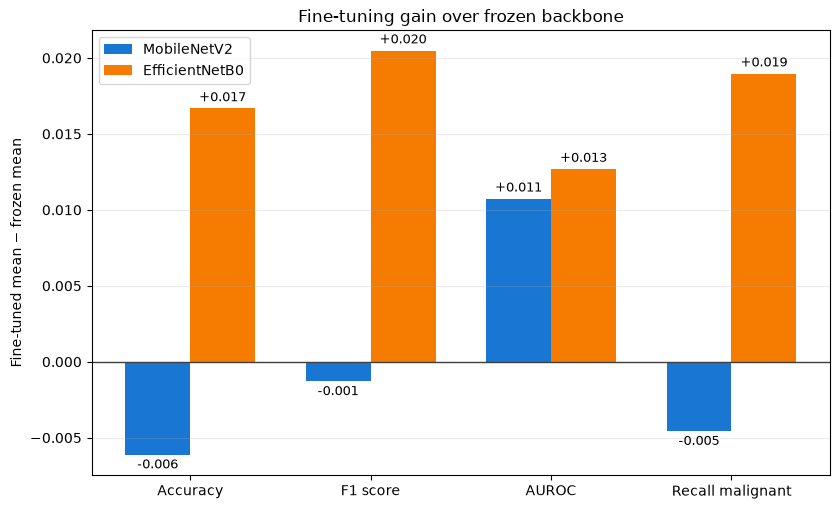

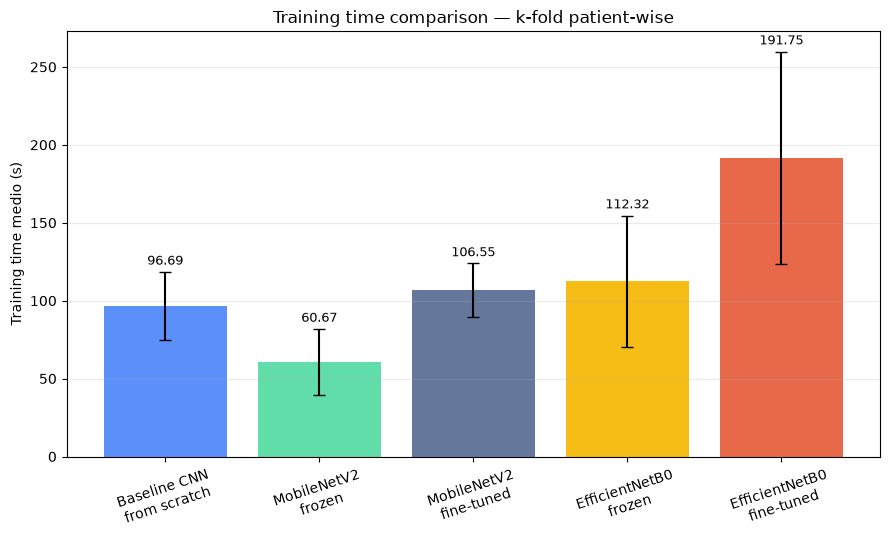

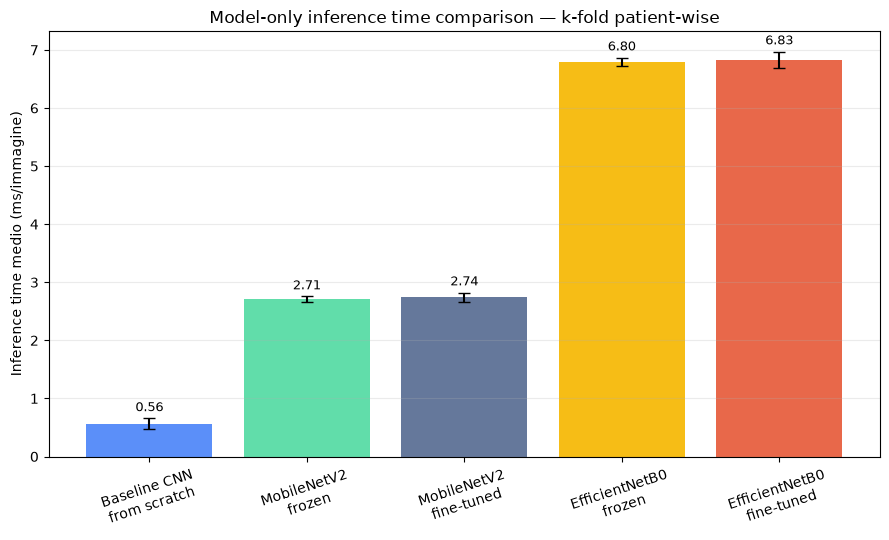

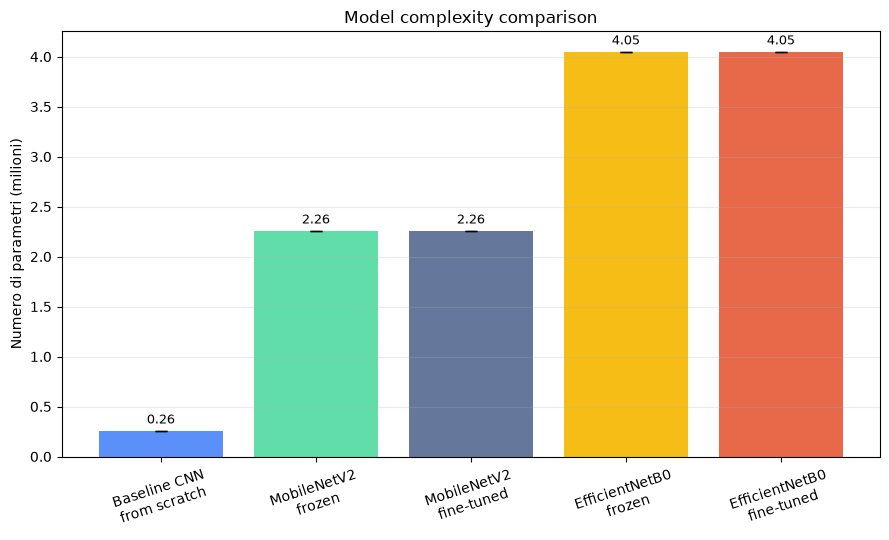

Figure aggregate salvate:
- /Users/bertu/Projects/HistoBreastNet/results/03_transfer_learning/figures/roc_curves/roc_transfer_models.png
- /Users/bertu/Projects/HistoBreastNet/results/03_transfer_learning/figures/roc_curves/roc_transfer_models.pdf
- /Users/bertu/Projects/HistoBreastNet/results/03_transfer_learning/figures/confusion_matrices_aggregate/confusion_matrices_transfer_models.png
- /Users/bertu/Projects/HistoBreastNet/results/03_transfer_learning/figures/confusion_matrices_aggregate/confusion_matrices_transfer_models.pdf
- /Users/bertu/Projects/HistoBreastNet/results/03_transfer_learning/figures/confusion_matrices_aggregate/confusion_matrix_efficientnetb0_finetuned.png
- /Users/bertu/Projects/HistoBreastNet/results/03_transfer_learning/figures/confusion_matrices_aggregate/confusion_matrix_efficientnetb0_finetuned.pdf
- /Users/bertu/Projects/HistoBreastNet/results/03_transfer_learning/figures/confusion_matrices_aggregate/confusion_matrix_baseline_vs_best_transfer.png
- /Users/b

In [13]:
# Metriche k-fold, guadagno del fine-tuning ed efficienza computazionale.
# I grafici k-fold mostrano media e deviazione standard; il confronto generale
# include la baseline quando sono disponibili righe compatibili.
# Usa il confronto comprensivo di baseline quando disponibile; altrimenti usa il solo transfer.
summary_for_plot = comparison_df if comparison_df is not None else summary_df
summary_source = comparison_path.name if comparison_df is not None else summary_path.name
summary_rows = select_config_rows(summary_for_plot, COMPARISON_SPECS, summary_source)

# Le quattro metriche riassumono prestazione generale, equilibrio tra classi,
# ranking probabilistico e sensibilità sulla classe maligna.
metric_specs = [
    ('accuracy', 'Accuracy'),
    ('f1', 'F1 score'),
    ('auroc', 'AUROC'),
    ('recall_malignant', 'Recall malignant'),
]
x_positions = np.arange(len(COMPARISON_SPECS))
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True, constrained_layout=True)
# Altezza delle barre = media tra fold; barre d'errore = deviazione standard tra fold.
for ax, (metric_key, metric_label) in zip(axes.flat, metric_specs):
    mean_column = require_column(
        summary_rows, [f'{metric_key}_mean'], summary_source, f'media {metric_key}'
    )
    std_column = require_column(
        summary_rows, [f'{metric_key}_std'], summary_source, f'deviazione standard {metric_key}'
    )
    means = pd.to_numeric(summary_rows[mean_column], errors='raise').to_numpy()
    errors = pd.to_numeric(summary_rows[std_column], errors='coerce').fillna(0).to_numpy()
    bars = ax.bar(x_positions, means, yerr=errors, capsize=4, color='#3979A8', alpha=0.9)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
    ax.set_title(metric_label)
    ax.set_ylim(0, min(1.15, max(1.02, float(np.nanmax(means + errors)) + 0.12)))
    ax.grid(axis='y', alpha=0.25)
    ax.set_xticks(x_positions, [MODEL_LABELS[spec] for spec in COMPARISON_SPECS], rotation=18)
fig.suptitle(
    'K-fold patient-wise comparison: CNN baseline vs transfer learning', fontsize=16
)
saved_figure_paths.extend(
    save_png_pdf(fig, REPORT_FIGURES_DIR / 'kfold_metric_comparison')
)
plt.show()
plt.close(fig)

# Il guadagno fine-tuned − frozen riguarda soltanto i backbone transfer:
# la CNN addestrata da zero non possiede i due stage e viene quindi esclusa.
transfer_summary_rows = select_config_rows(summary_df, TRANSFER_SPECS, summary_path.name)
gain_values = {'mobilenetv2': [], 'efficientnetb0': []}
for metric_key, _ in metric_specs:
    mean_column = require_column(
        transfer_summary_rows, [f'{metric_key}_mean'], summary_path.name, f'media {metric_key}'
    )
    for backbone in gain_values:
        frozen_value = pd.to_numeric(
            transfer_summary_rows.loc[
                (transfer_summary_rows['_model_key'] == backbone)
                & (transfer_summary_rows['_mode_key'] == 'frozen'), mean_column
            ], errors='raise'
        ).iloc[0]
        finetuned_value = pd.to_numeric(
            transfer_summary_rows.loc[
                (transfer_summary_rows['_model_key'] == backbone)
                & (transfer_summary_rows['_mode_key'] == 'finetuned'), mean_column
            ], errors='raise'
        ).iloc[0]
        # Valore positivo: il fine-tuning supera lo stage frozen per quella metrica.
        gain_values[backbone].append(finetuned_value - frozen_value)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
width = 0.36
metric_positions = np.arange(len(metric_specs))
for offset, (backbone, values), color in zip(
    [-width / 2, width / 2], gain_values.items(), ['#1976D2', '#F57C00']
):
    bars = ax.bar(
        metric_positions + offset, values, width,
        label='MobileNetV2' if backbone == 'mobilenetv2' else 'EfficientNetB0', color=color
    )
    ax.bar_label(bars, fmt='%+.3f', padding=3, fontsize=9)
ax.axhline(0, color='0.25', linewidth=1)
ax.set_xticks(metric_positions, [label for _, label in metric_specs])
ax.set_ylabel('Fine-tuned mean − frozen mean')
ax.set_title('Fine-tuning gain over frozen backbone')
ax.legend()
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
saved_figure_paths.extend(save_png_pdf(fig, REPORT_FIGURES_DIR / 'finetuning_gain'))
plt.show()
plt.close(fig)

efficiency_configured = add_canonical_config(efficiency_df, efficiency_path.name)
efficiency_configured = efficiency_configured[
    efficiency_configured.apply(
        lambda row: (row['_model_key'], row['_mode_key']) in COMPARISON_SPECS, axis=1
    )
].copy()

# Aggrega per configurazione le misure di efficienza disponibili nelle singole fold.
def aggregate_efficiency(column_candidates, purpose):
    value_column = require_column(
        efficiency_configured, column_candidates, efficiency_path.name, purpose
    )
    values = efficiency_configured.copy()
    values['_plot_value'] = pd.to_numeric(values[value_column], errors='coerce')
    values = values.dropna(subset=['_plot_value'])
    aggregated = (
        values.groupby(['_model_key', '_mode_key'], as_index=False)['_plot_value']
        .agg(['mean', 'std']).reset_index()
    )
    aggregated['std'] = aggregated['std'].fillna(0)
    return aggregated

# Cerca una misura di inferenza compatibile senza sostituire o stimare colonne assenti.
def extract_inference_measure(df, spec, column_candidates):
    if df is None or df.empty:
        return None
    rows = df.copy()
    model_column = next(
        (name for name in ['model', 'model_name', 'backbone'] if name in rows.columns), None
    )
    if model_column is None:
        return None
    model_keys = rows[model_column].map(canonical_token)
    accepted_model_keys = (
        ['baselinecnn', 'cnnbaseline']
        if spec == ('baselinecnn', 'fromscratch') else [spec[0]]
    )
    rows = rows[model_keys.isin(accepted_model_keys)].copy()
    mode_column = next(
        (name for name in ['training_mode', 'mode', 'phase'] if name in rows.columns), None
    )
    if mode_column is not None:
        rows = rows[rows[mode_column].map(canonical_token) == spec[1]].copy()
    elif spec != ('baselinecnn', 'fromscratch'):
        return None
    if rows.empty:
        return None
    value_column = next((name for name in column_candidates if name in rows.columns), None)
    if value_column is None:
        return None
    values = pd.to_numeric(rows[value_column], errors='coerce').dropna()
    if values.empty:
        return None
    if value_column.endswith('_mean'):
        mean_value = float(values.iloc[-1])
        std_column = value_column[:-5] + '_std'
        std_values = (
            pd.to_numeric(rows[std_column], errors='coerce').dropna()
            if std_column in rows.columns else pd.Series(dtype=float)
        )
        std_value = float(std_values.iloc[-1]) if not std_values.empty else 0.0
    else:
        mean_value = float(values.mean())
        std_value = float(values.std(ddof=1)) if len(values) > 1 else 0.0
    return {'mean': mean_value, 'std': std_value}

# Più CSV possono contenere la stessa misura con nomi diversi: si usa la prima sorgente
# realmente disponibile, senza derivare valori da colonne non presenti.
def first_available_inference_measure(sources, spec, column_candidates):
    for source_df in sources:
        measure = extract_inference_measure(source_df, spec, column_candidates)
        if measure is not None:
            return measure
    return None

# Funzione comune per salvare i grafici di tempo, latenza e complessità in PNG/PDF.
def plot_efficiency(aggregated, specs, title, ylabel, base_name, scale=1.0):
    available_specs = [
        spec for spec in specs
        if ((aggregated['_model_key'] == spec[0]) & (aggregated['_mode_key'] == spec[1])).any()
    ]
    if not available_specs:
        raise ValueError(f'{efficiency_path.name}: nessun valore disponibile per {title}.')
    means, errors = [], []
    for spec in available_specs:
        row = aggregated[
            (aggregated['_model_key'] == spec[0]) & (aggregated['_mode_key'] == spec[1])
        ].iloc[0]
        means.append(row['mean'] / scale)
        errors.append(row['std'] / scale)
    fig, ax = plt.subplots(figsize=(9, 5.5))
    bars = ax.bar(
        np.arange(len(available_specs)), means, yerr=errors, capsize=4,
        color=['#5B8FF9', '#61DDAA', '#65789B', '#F6BD16', '#E8684A'][:len(available_specs)]
    )
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.set_xticks(
        np.arange(len(available_specs)), [MODEL_LABELS[spec] for spec in available_specs], rotation=18
    )
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    saved_figure_paths.extend(save_png_pdf(fig, REPORT_FIGURES_DIR / base_name))
    plt.show()
    plt.close(fig)

# Tempo di training: costo complessivo necessario per addestrare ciascuna configurazione.
training_aggregate = aggregate_efficiency(
    ['training_time_sec', 'training_time_sec_mean'], 'tempo di training'
)
plot_efficiency(
    training_aggregate, COMPARISON_SPECS, 'Training time comparison — k-fold patient-wise',
    'Training time medio (s)', 'efficiency_training_time'
)

# Ordine di preferenza per i transfer: model-only misura il solo costo della rete con input
# già caricati; il tempo end-to-end/inference generico può includere tf.data e lettura immagini.
transfer_inference_columns = [
    'model_only_inference_time_ms_per_image_mean',
    'model_only_inference_time_ms_per_image',
    'inference_time_ms_per_image_mean',
    'inference_time_ms_per_image',
]
# I CSV baseline storici possono esporre prima il nome generico; l'ordine differente
# preserva la misura realmente disponibile senza rinominarla o stimarla.
baseline_inference_columns = [
    'inference_time_ms_per_image_mean',
    'inference_time_ms_per_image',
    'model_only_inference_time_ms_per_image_mean',
    'model_only_inference_time_ms_per_image',
]
# Latenza model-only: isola il costo del modello da lettura file e pipeline tf.data.
inference_records = []
transfer_inference_sources = [comparison_df, summary_df, efficiency_df]
# Ogni configurazione transfer deve avere una misura compatibile per il grafico di latenza.
for spec in TRANSFER_SPECS:
    measure = first_available_inference_measure(
        transfer_inference_sources, spec, transfer_inference_columns
    )
    if measure is None:
        raise ValueError(
            f'Nessuna misura di inference time disponibile per {MODEL_LABELS[spec]}.'
        )
    inference_records.append(
        {'_model_key': spec[0], '_mode_key': spec[1], **measure}
    )

# Il tempo di inferenza baseline viene aggiunto solo se una colonna compatibile è presente;
# in caso contrario il grafico resta transfer-only senza stimare valori mancanti.
baseline_inference_sources = [
    comparison_df,
    baseline_summary_figure_df,
    efficiency_df,
    baseline_metrics_figure_df,
]
baseline_spec = ('baselinecnn', 'fromscratch')
baseline_inference_measure = first_available_inference_measure(
    baseline_inference_sources, baseline_spec, baseline_inference_columns
)
if baseline_inference_measure is None:
    warnings.warn(
        'Nessuna misura di inference time trovata per la CNN baseline: '
        'efficiency_inference_time resta transfer-only.'
    )
else:
    inference_records.insert(
        0, {'_model_key': baseline_spec[0], '_mode_key': baseline_spec[1],
            **baseline_inference_measure}
    )
inference_aggregate = pd.DataFrame(inference_records)
plot_efficiency(
    inference_aggregate, COMPARISON_SPECS,
    'Model-only inference time comparison — k-fold patient-wise',
    'Inference time medio (ms/immagine)', 'efficiency_inference_time'
)

# Il grafico di complessità confronta il numero di parametri, indipendente dall'hardware;
# model_size_mb resta nelle tabelle D1 perché dipende anche dal formato di serializzazione.
complexity_aggregate = aggregate_efficiency(
    ['n_params', 'n_params_mean'], 'numero di parametri'
)
plot_efficiency(
    complexity_aggregate, COMPARISON_SPECS, 'Model complexity comparison',
    'Numero di parametri (milioni)', 'efficiency_model_complexity', scale=1_000_000
)

# Completa gli artefatti del report salvando anche il formato PDF delle curve esistenti.
def save_training_curve_pdf_from_png(png_path):
    pdf_path = png_path.with_suffix('.pdf')
    if pdf_path.exists():
        return None
    image = plt.imread(png_path)
    height, width = image.shape[:2]
    figure = plt.figure(figsize=(width / 150, height / 150), dpi=150)
    axis = figure.add_axes([0, 0, 1, 1])
    axis.imshow(image)
    axis.axis('off')
    figure.savefig(pdf_path, format='pdf', bbox_inches='tight', pad_inches=0)
    plt.close(figure)
    return pdf_path

training_curve_pngs = list((FIGURES_DIR / 'training_curves').glob('*.png'))
training_curve_pngs.extend(EXPERIMENTS_DIR.glob('*/training_curves.png'))
for training_curve_png in training_curve_pngs:
    training_curve_pdf = save_training_curve_pdf_from_png(training_curve_png)
    if training_curve_pdf is not None:
        saved_figure_paths.append(training_curve_pdf)

print('Figure aggregate salvate:')
for saved_path in saved_figure_paths:
    print('-', saved_path)